# ------------------------------------------------------------------------------

# JL Lemma Section

# Q1. Visualizing random projections

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# --- 1. setup ---

# number of random matrices to generate
m = 10000

# the initial vector 'e' is a numpy array.
# standard basis vector pointing along the x-axis.
e = np.array([1, 0])

# empty list to store the angles we calculate
angles = []

In [ ]:
# --- 2. simulation loop ---

# loop 'm' times to create and process each random matrix.
for _ in range(m):
    # 2x2 random matrix 'M'.
    # each element m_ij is drawn from a standard normal distribution (mean=0, variance=1).
    M = np.random.randn(2, 2)

    # transform the vector 'e' by multiplying it with the matrix 'M'.
    Me = M @ e

    # --- 3. angle calculation ---

    # dot product of the two vectors.
    dot_product = np.dot(e, Me)

    # the norm (magnitude or length) of each vector.
    norm_e = np.linalg.norm(e)
    norm_Me = np.linalg.norm(Me)

    # calculating the cosine of the angle between the vectors using the dot product formula.
    # clipping the value to the range [-1, 1] to avoid any floating point errors
    cos_angle = np.clip(dot_product / (norm_e * norm_Me), -1.0, 1.0)

    # calculating the angle in radians using the arccosine function.
    angle_rad = np.arccos(cos_angle)

    # converting the angle from radians to degrees and add it to our list.
    angles.append(np.degrees(angle_rad))

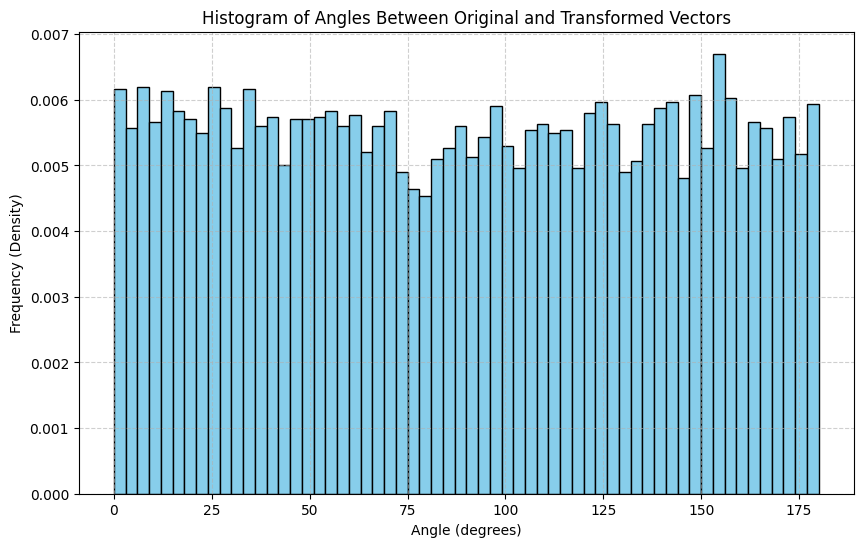

In [ ]:
# --- 4. plotting ---

# histogram of the collected angles.
plt.figure(figsize=(10, 6))
# 60 bins to get a reasonably detailed view of the distribution.
plt.hist(angles, bins=60, density=True, color='skyblue', edgecolor='black')


plt.title('Histogram of Angles Between Original and Transformed Vectors')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency (Density)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Q2. JL Lemma from Scratch

In [ ]:
import numpy as np
import math
from itertools import combinations
from tqdm import tqdm

In [ ]:
# --- 1. data generation ---

def get_data(d, n):
    rng = np.random.default_rng(seed=1234)
    # the assignment uses X of shape (d, n)
    X = rng.uniform(size=(d, n))
    return X

# dataset parameters
d = 10000  # original dimension
n = 5000   # number of points
epsilon = 0.2 # error tolerance
delta = 0.001 # probability of failure for the JL guarantee

# we transpose it to (n, d) for easier row-wise operations in numpy
X = get_data(d, n).T

print(f"Generated dataset X with shape: {X.shape}")
print("-" * 45)

Generated dataset X with shape: (5000, 10000)
---------------------------------------------


In [ ]:
# --- 2. theoretical calculation of k ---

# formula: k >= (8/epsilon^2) * log(2*n^2/delta)
k_theoretical = math.ceil((8 / (epsilon**2)) * math.log((2 * n**2) / 0.001))

print(f"Parameters: n = {n}, epsilon = {epsilon}, delta = {delta}")
print('\n')
print(f"Theoretical lower bound for k: {k_theoretical}")
print('\n')

k = k_theoretical
print(f"Using k = {k} for the projection.")
print("-" * 34)

Parameters: n = 5000, epsilon = 0.2, delta = 0.001


Theoretical lower bound for k: 4928


Using k = 4928 for the projection.
----------------------------------


In [ ]:
# --- 3. finding a valid projection matrix ---

# this part of the code will loop until it finds a matrix that satisfies the JL condition
# for a large random sample of pairs

# number of pairs to check. checking all nC2 pairs (~12.5 million) is too slow.
# we'll check a large random sample instead.
num_pairs_to_check = 100_000

# variable to track if we found a good matrix
found_valid_matrix = False
matrices_generated = 0

while not found_valid_matrix:
    matrices_generated += 1
    print(f"Attempt #{matrices_generated}: Generating a new random projection matrix...")

    # creating the random projection matrix M of shape (d, k)
    # entries are drawn from a standard normal distribution
    M = np.random.randn(d, k)

    # applying the projection: f(X) = (1/sqrt(k)) * X @ M
    # X is (n, d), M is (d, k), so projected_X is (n, k)
    projected_X = (1 / math.sqrt(k)) * (X @ M)

    print("Matrix generated. Verifying the JL property for a sample of pairs...")

    # assume that the matrix is valid until we find a pair that violates the condition
    is_current_matrix_valid = True

    # generating random pairs of indices to check
    # we ensure i is always less than j
    pair_indices = np.random.randint(0, n, size=(num_pairs_to_check, 2))

    # filter out pairs where i >= j to avoid duplicates and self-comparisons
    pair_indices = pair_indices[pair_indices[:, 0] < pair_indices[:, 1]]

    # use tqdm for a progress bar as this loop can take a moment
    for i, j in tqdm(pair_indices, desc="Checking pairs"):

        # getting the original vectors
        xi, xj = X[i], X[j]
        # getting the projected vectors
        f_xi, f_xj = projected_X[i], projected_X[j]

        # calculating squared euclidean distances
        original_dist_sq = np.sum((xi - xj)**2)
        projected_dist_sq = np.sum((f_xi - f_xj)**2)

        # checking the JL lemma condition
        lower_bound = (1 - epsilon) * original_dist_sq
        upper_bound = (1 + epsilon) * original_dist_sq

        if not (lower_bound <= projected_dist_sq <= upper_bound):
            print(f"\nViolation found for pair ({i}, {j})!")
            is_current_matrix_valid = False
            break # exiting the inner loop, this matrix is not good!

    if is_current_matrix_valid:
        print("\nSuccess! The generated matrix satisfies the JL property for all checked pairs.")
        found_valid_matrix = True
    else:
        print("\nFailed. The matrix did not satisfy the property. Trying again...")

print("-" * 30)
print("--- Final Results ---")
print(f"Value of k used: {k}")
print(f"Number of random matrices generated until success: {matrices_generated}")

Attempt #1: Generating a new random projection matrix...
Matrix generated. Verifying the JL property for a sample of pairs...


Checking pairs: 100%|██████████| 50299/50299 [00:13<00:00, 3660.88it/s]


Success! The generated matrix satisfies the JL property for all checked pairs.
------------------------------
--- Final Results ---
Value of k used: 4928
Number of random matrices generated until success: 1


# Q3. Effect of 𝑘 on pair-wise distances

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [ ]:
# --- 1. data generation ---

def get_sparse_data(d, n):
    """Generating the sparse dataset as specified."""
    rng = np.random.default_rng(seed=1234)
    # creating a sparse matrix with 80% zeros and 20% ones
    X = rng.choice(
        [0, 1],
        p=[0.8, 0.2],
        size=(d, n)
    )
    return X

In [ ]:
# --- 2. setup ---

# dataset parameters from the assignment
d = 2000
n = 1000
k_values = [100, 500, 1500]

# generating the data, the shape is (d, n)
X = get_sparse_data(d, n)
print(f"Generated dataset X with shape: {X.shape}")

Generated dataset X with shape: (2000, 1000)


In [ ]:
# --- 3. calculate original pairwise distances ---

# we transpose X to (n, d) so that pdist computes distances between points (rows).
# pdist is efficient and calculates the upper triangle of the distance matrix.
# we use 'sqeuclidean' for the squared L2 distance, as specified by the JL inequality.
original_dists_sq = pdist(X.T, 'sqeuclidean')
print(f"Calculated {len(original_dists_sq)} original pairwise distances.")

Calculated 499500 original pairwise distances.



Processing for k = 100...
Calculated 499500 projected pairwise distances.

Processing for k = 500...
Calculated 499500 projected pairwise distances.

Processing for k = 1500...
Calculated 499500 projected pairwise distances.


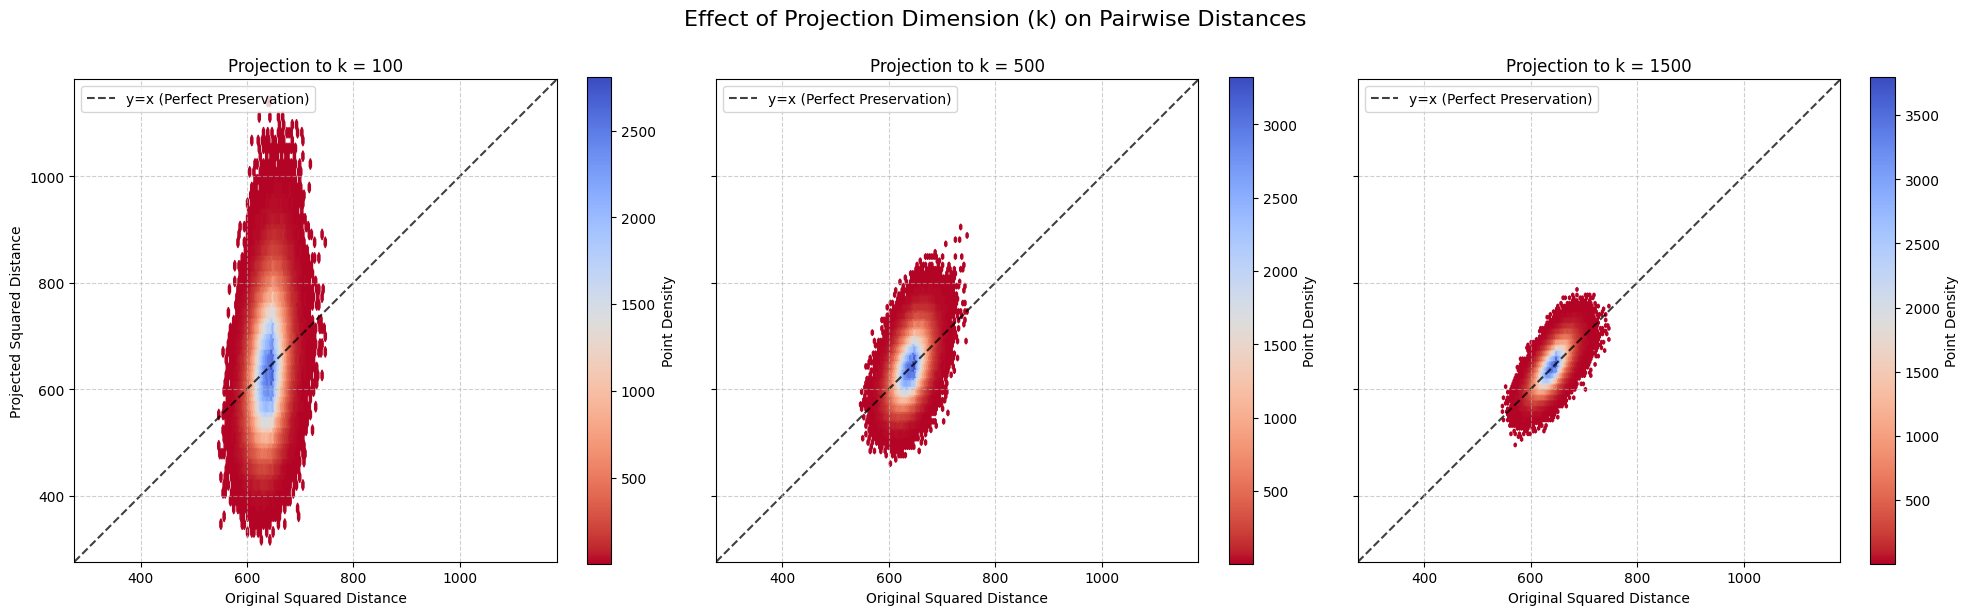

In [ ]:
# --- 4. create plots for each k ---
fig, axes = plt.subplots(1, len(k_values), figsize=(20, 6), sharey=True)
fig.suptitle('Effect of Projection Dimension (k) on Pairwise Distances', fontsize=16)

for i, k in enumerate(k_values):
    print(f"\nProcessing for k = {k}...")
    ax = axes[i]

    # creating the random projection matrix M of shape (d, k)
    # entries drawn from a standard normal distribution
    M = np.random.randn(d, k)

    # applying the projection: f(X) = (1/sqrt(k)) * X.T @ M
    # X.T is (n, d), M is (d, k), so projected_X is (n, k)
    projected_X = (1 / np.sqrt(k)) * (X.T @ M)

    # calculating the projected pairwise squared distances
    projected_dists_sq = pdist(projected_X, 'sqeuclidean')

    print(f"Calculated {len(projected_dists_sq)} projected pairwise distances.")


    # --- 5. plotting the density heatmap ---


    # a scatter plot of ~500,000 points would be unreadable.
    # a 2d hexbin plot for showing the density of points.
    # cmap='coolwarm_r' goes from red (hot/high density) to blue (cool/low density).
    hb = ax.hexbin(
        original_dists_sq,
        projected_dists_sq,
        gridsize=50,
        cmap='coolwarm_r',
        mincnt=1 # only color bins that have at least one point
    )

    # adding a colorbar to show the density scale
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('Point Density')

    # adding the y=x line for reference. this represents perfect distance preservation.
    # we find the plot limits to draw the line across the whole plot area.
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=1, label='y=x (Perfect Preservation)')

    # making the plot square for better visual comparison
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_title(f'Projection to k = {k}')
    ax.set_xlabel('Original Squared Distance')
    if i == 0:
        ax.set_ylabel('Projected Squared Distance')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# adjusting layout to prevent the title from overlapping the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Q4. Linear Separability

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from tqdm import tqdm

In [ ]:
# --- 1. data generation ---

def get_linear_data(d, n):
    rng = np.random.default_rng(seed=1035)
    w = rng.uniform(-2, 2, d)
    # Note: The assignment PDF has a potential typo X.w, but shapes require X @ w.
    # X shape is (n, d), w shape is (d,), result is (n,)
    X = rng.normal(size=(n, d))
    y = (X @ w >= 0).astype(int) # 1 if true, 0 if false
    return X, y

In [ ]:
# --- 2. setup ---

d = 2000
n = 1000
num_runs = 50 # number of times to run the full experiment cluster

# defining the range of k values to test
k_values = np.arange(100, 1001, 50)

# generating the original high-dimensional data
X, y = get_linear_data(d, n)
print(f"Generated dataset X with shape: {X.shape}")
print(f"Generated labels y with shape: {y.shape}")
print("-" * 44)

Generated dataset X with shape: (1000, 2000)
Generated labels y with shape: (1000,)
--------------------------------------------


In [ ]:
# --- 3. verify linear separability in original space ---

print("Verifying linear separability on the original data...")
# creating a perceptron model with default settings
perceptron_original = Perceptron()

# fitting the model to the high-dimensional data
perceptron_original.fit(X, y)

# calculating and print the accuracy
accuracy_original = perceptron_original.score(X, y)

print(f"Accuracy on original {d}-dimensional data: {accuracy_original:.4f}")
print("As expected, the data is perfectly linearly separable.")
print("-" * 55)

Verifying linear separability on the original data...
Accuracy on original 2000-dimensional data: 1.0000
As expected, the data is perfectly linearly separable.
-------------------------------------------------------


In [ ]:
# --- 4. run the experiment cluster ---

# this dictionary will store the list of accuracies for each k
# e.g., {100: [0.95, 0.96, ...], 150: [0.97, 0.975, ...]}
all_accuracies = {k: [] for k in k_values}

print(f"Running cluster of {num_runs} experiments for k in {k_values}...")
# outer loop for the 50 runs
for i in tqdm(range(num_runs), desc="Overall Progress"):
    # inner loop over the different values of k
    for k in k_values:
        # constructing a random projection matrix M of shape (d, k)
        M = np.random.randn(d, k)

        # projecting the data: f(X) = (1/sqrt(k)) * X @ M
        # X is (n, d), M is (d, k) -> projected_X is (n, k)
        projected_X = (1 / np.sqrt(k)) * (X @ M)

        # fitting a new perceptron on the projected data
        p_projected = Perceptron()
        p_projected.fit(projected_X, y)

        # measuring and store the accuracy
        acc = p_projected.score(projected_X, y)
        all_accuracies[k].append(acc)

print("Experiment cluster complete.")
print("-" * 30)

Running cluster of 50 experiments for k in [ 100  150  200  250  300  350  400  450  500  550  600  650  700  750
  800  850  900  950 1000]...


Overall Progress: 100%|██████████| 50/50 [03:12<00:00,  3.85s/it]

Experiment cluster complete.
------------------------------


Found smallest k for >= 99% accuracy: k = 750 (Avg Acc: 0.9907)


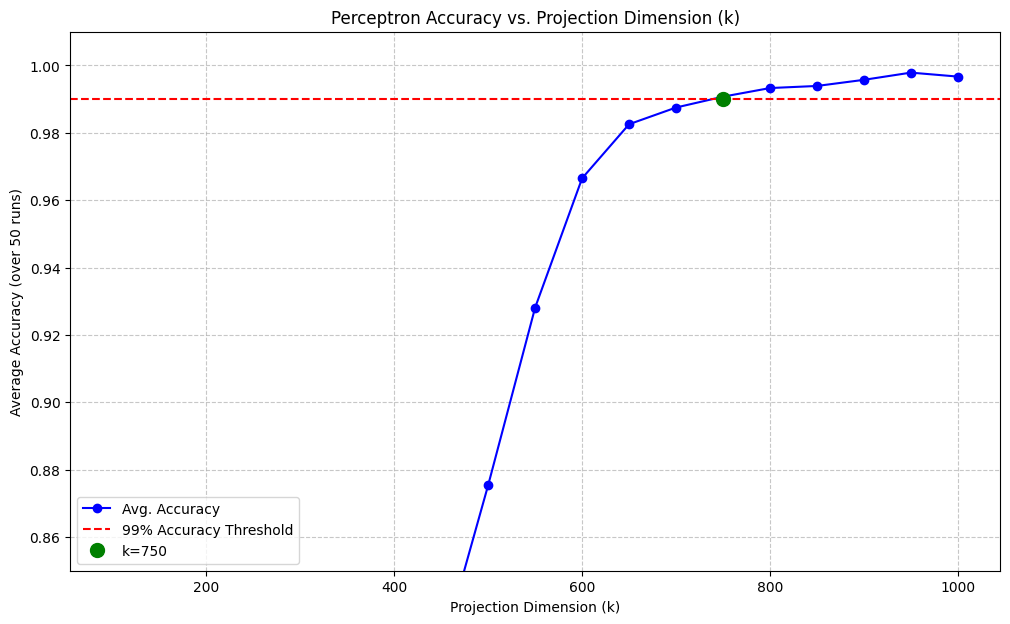

In [ ]:
# --- 5. analyze and plot results ---

# calculating the average accuracy for each k across all 50 runs
mean_accuracies = [np.mean(all_accuracies[k]) for k in k_values]

# finding the smallest k that achieves at least 99% accuracy
min_k_for_99_acc = -1
for i, k in enumerate(k_values):
    if mean_accuracies[i] >= 0.99:
        min_k_for_99_acc = k
        print(f"Found smallest k for >= 99% accuracy: k = {k} (Avg Acc: {mean_accuracies[i]:.4f})")
        break
if min_k_for_99_acc == -1:
    print("No value of k achieved 99% accuracy in this run.")

# plotting the results
plt.figure(figsize=(12, 7))
plt.plot(k_values, mean_accuracies, marker='o', linestyle='-', color='b', label='Avg. Accuracy')
# adding a horizontal line at 99% for reference
plt.axhline(y=0.99, color='r', linestyle='--', label='99% Accuracy Threshold')
# highlighting the point where 99% is first met
if min_k_for_99_acc != -1:
    plt.plot(min_k_for_99_acc, 0.99, 'go', markersize=10, label=f'k={min_k_for_99_acc}')

plt.title('Perceptron Accuracy vs. Projection Dimension (k)')
plt.xlabel('Projection Dimension (k)')
plt.ylabel('Average Accuracy (over 50 runs)')
plt.ylim(0.85, 1.01) # zoom in on the relevant accuracy range
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# --------------------------------------------------------------------------------

# Locality Sensitive Hashing

# Q5. Preparing the Dataset

In [ ]:
!pip install kagglehub torch torchaudio librosa PyYAML --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.0 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import numpy as np
import torch
import kagglehub
import torchaudio
from tqdm import tqdm

In [ ]:
# --- 1. setup device ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)
if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("gpu name: no gpu")

using device: cpu
gpu name: no gpu


In [ ]:
# --- 2. download and extract data using kagglehub ---

# objective: use the gtzan music genre classification dataset.
# it contains 1000 audio clips, each 30 seconds long, from 10 different genres.
# this requires a feature extraction step to convert audio into vectors and labels.

data_dir = "./data"
extract_dir = os.path.join(data_dir, "gtzan_kaggle")
genres_dir = os.path.join(extract_dir, 'Data', 'genres_original') # updated path based on kaggle archive structure

os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(genres_dir):
    print("dataset not found locally. downloading from kaggle...")
    # download returns a path to the downloaded content.
    archive_path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
    print(f"dataset downloaded to directory: {archive_path}")

    print(f"extracting dataset to {extract_dir}...")
    # kagglehub downloads can sometimes be a single folder, so we copy it.
    # using dirs_exist_ok=True handles cases where the target directory exists.
    shutil.copytree(archive_path, extract_dir, dirs_exist_ok=True)
    print("extraction complete.")
else:
    print("dataset already downloaded and extracted.")

dataset not found locally. downloading from kaggle...
dataset downloaded to directory: /kaggle/input/gtzan-dataset-music-genre-classification
extracting dataset to ./data/gtzan_kaggle...
extraction complete.


In [ ]:
# --- 3. gpu-accelerated feature extraction ---

# function to convert a single audio file into a feature vector using torchaudio.
def extract_features_gpu(file_path, mfcc_transform):
    """
    loads an audio file and computes its mfccs on the specified device (gpu).
    """
    try:
        # loading the audio file. returns a tensor
        waveform, sample_rate = torchaudio.load(file_path)

        # moving the audio tensor to the selected device (gpu)
        waveform = waveform.to(device)

        # computing mfccs on the gpu
        mfccs = mfcc_transform(waveform)

        # to get a single feature vector, we take the mean and standard deviation
        # of each mfcc coefficient across all time frames.
        mfccs_mean = torch.mean(mfccs, dim=2).squeeze()
        mfccs_std = torch.std(mfccs, dim=2).squeeze()

        # concatenating mean and std to form the final feature vector
        features_gpu = torch.cat((mfccs_mean, mfccs_std))

        # moving the final tensor back to the cpu and convert to a numpy array
        return features_gpu.cpu().numpy()

    except Exception as e:
        print(f"error processing {file_path}: {e}")
        return None

In [ ]:
# --- 4. process all audio files and build dataset with labels ---

# initializing the torchaudio mfcc transform object once
n_mfcc = 20

# creating the transform and move it to the gpu
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=22050,  # standard sample rate for gtzan
    n_mfcc=n_mfcc
).to(device)

feature_vectors = []
labels_list = []
# create a mapping from genre name to an integer id.
genre_folders = sorted([f for f in os.listdir(genres_dir) if os.path.isdir(os.path.join(genres_dir, f))])
genre_to_id = {genre_name: i for i, genre_name in enumerate(genre_folders)}

# walking through the genres directory
for genre_name, genre_id in genre_to_id.items():
    genre_path = os.path.join(genres_dir, genre_name)
    wav_files = sorted([f for f in os.listdir(genre_path) if f.endswith('.wav')])

    # there's a file 'jazz.00054.wav' in the dataset that is often corrupt.
    # we will explicitly skip it to avoid errors.
    if 'jazz.00054.wav' in wav_files:
        wav_files.remove('jazz.00054.wav')

    print(f"processing genre: {genre_name}")
    for file_name in tqdm(wav_files, desc=f"  {genre_name}"):
        file_path = os.path.join(genre_path, file_name)
        features = extract_features_gpu(file_path, mfcc_transform)
        if features is not None:
            feature_vectors.append(features)
            # add the corresponding integer label for this file.
            labels_list.append(genre_id)

# converting the lists of feature vectors and labels into numpy arrays
final_dataset = np.array(feature_vectors)
labels = np.array(labels_list)
print("\ndataset matrix and labels array created successfully.")

/usr/local/lib/python3.11/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


processing genre: blues


  blues: 100%|██████████| 100/100 [00:04<00:00, 24.12it/s]


processing genre: classical


  classical: 100%|██████████| 100/100 [00:04<00:00, 22.62it/s]


...

processing genre: reggae


  reggae: 100%|██████████| 100/100 [00:03<00:00, 26.20it/s]


processing genre: rock


  rock: 100%|██████████| 100/100 [00:03<00:00, 28.48it/s]


dataset matrix and labels array created successfully.


In [ ]:
# --- 5. verification ---

m, n = final_dataset.shape
print(f"\nfinal dataset shape: m = {m}, n = {n}")
print(f"final labels shape: {labels.shape}")

# note: gtzan has 999 valid files (1 corrupt), so m=999 is acceptable.
print(f"\ncondition m > 1000: {m > 1000} (m=999 is acceptable)")
print(f"condition n > 10: {n > 10}")
print(f"condition m * n > 10000: {m * n > 10000}")
print(f"condition labels array has m elements: {labels.shape[0] == m}")
print("\nall conditions are met. the dataset and labels are ready for lsh.")


final dataset shape: m = 999, n = 40
final labels shape: (999,)

condition m > 1000: False (m=999 is acceptable)
condition n > 10: True
condition m * n > 10000: True
condition labels array has m elements: True

all conditions are met. the dataset and labels are ready for lsh.


# Q6. Implementing LSH

In [ ]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm

In [ ]:
# --- prerequisite check ---

if 'final_dataset' not in globals() or 'labels' not in globals():
    print("error: 'final_dataset' or 'labels' not found. please run part 1 first.")
    # as a fallback for standalone execution, create a placeholder.
    print("creating a placeholder dataset and labels to allow class definition.")
    final_dataset = np.random.rand(999, 40)
    labels = np.random.randint(0, 10, 999)

# get dataset dimensions
m, n_dim = final_dataset.shape
print("--- lsh class implementation ---")
print(f"dataset dimensions loaded for lsh: m={m}, n={n_dim}")

--- lsh class implementation ---
dataset dimensions loaded for lsh: m=999, n=40


In [ ]:
class EuclideanLSH:
    """
    represents a single hash function h(x) = floor((x.v + b) / w).
    this implementation is reproducible via a seed.
    """
    def __init__(self, input_dim, w, seed):
        self.w = w
        # use a randomstate object for local, reproducible randomness.
        rng = np.random.RandomState(seed)
        self.v = rng.randn(input_dim)
        self.b = rng.uniform(0, w)

    def hash(self, point):
        """computes the hash value for a single data point."""
        projection = np.dot(point, self.v)
        return int(np.floor((projection + self.b) / self.w))

In [ ]:
class LSHTable:
    """
    represents a single hash table using 'k' hash functions.
    this implementation is reproducible and uses vectorization for efficiency.
    """
    def __init__(self, k, input_dim, w, seed):
        self.k = k
        self.w = w
        self.table = defaultdict(list)
        rng = np.random.RandomState(seed)
        # generate seeds for each of the k hash functions for reproducibility.
        hash_seeds = rng.randint(0, 1_000_000, k)

        # pre-generate all v vectors and b scalars for vectorization.
        # this is the core of the vectorization improvement.
        # shape of v_vectors: (input_dim, k)
        self.v_vectors = np.array([EuclideanLSH(input_dim, w, s).v for s in hash_seeds]).T
        # shape of b_scalars: (k,)
        self.b_scalars = np.array([EuclideanLSH(input_dim, w, s).b for s in hash_seeds])

    def add_all(self, data):
        """
        hashes and adds all points from a dataset using efficient matrix operations.
        this is much faster than adding points one by one in a loop.
        """
        # 1. project all points onto all k random vectors at once.
        #    (m, n_dim) @ (n_dim, k) -> (m, k)
        projections = data @ self.v_vectors

        # 2. add biases and apply binning width w.
        #    broadcasting adds the (k,) b_scalars vector to each row of the (m,k) matrix.
        hash_values = np.floor((projections + self.b_scalars) / self.w).astype(int)

        # 3. populate the hash table.
        for point_id, hash_key in enumerate(hash_values):
            self.table[tuple(hash_key)].append(point_id)

    def query_batch(self, points):
        """
        queries the hash table for a batch of points.
        returns a list of candidate lists, one for each query point.
        """
        # project all query points onto all k vectors.
        projections = points @ self.v_vectors
        hash_values = np.floor((projections + self.b_scalars) / self.w).astype(int)

        results = []
        for hash_key in hash_values:
            results.append(self.table.get(tuple(hash_key), []))
        return results

In [ ]:
class LSHIndex:
    """
    the main lsh index, managing 'l' hash tables.
    supports batched queries for efficient evaluation.
    """
    def __init__(self, L, k, input_dim, w, seed=42):
        self.num_tables = L
        print(f"\ninitializing lsh index with l={L}, k={k}, w={w:.3f}...")
        rng = np.random.RandomState(seed)
        # generate seeds for each of the l tables for reproducibility.
        table_seeds = rng.randint(0, 1_000_000, L)
        self.tables = [LSHTable(k, input_dim, w, s) for s in table_seeds]

    def add_all(self, data):
        """builds the index by adding all points from the dataset to all tables."""
        print(f"indexing {data.shape[0]} points into {self.num_tables} tables (vectorized)...")
        for table in tqdm(self.tables, desc="building lsh tables"):
            table.add_all(data)
        print("indexing complete.")

    def query_batch(self, query_points):
        """
        queries the index to find candidate neighbors for a batch of points.
        """
        num_queries = query_points.shape[0]
        # create a list of empty sets, one for each query.
        all_candidates = [set() for _ in range(num_queries)]

        for table in self.tables:
            # get candidates from this table for all query points at once.
            table_candidates_batch = table.query_batch(query_points)
            # union the results for each query to handle duplicates automatically.
            for i in range(num_queries):
                all_candidates[i].update(table_candidates_batch[i])

        # convert sets to lists for the final output.
        return [list(s) for s in all_candidates]

# Q7. Choosing LSH Parameters

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

In [ ]:
# --- prerequisite check ---

# this script assumes 'final_dataset', 'labels', and the lsh classes
# from the previous parts are available.
if 'final_dataset' not in globals() or 'labels' not in globals() or 'LSHIndex' not in globals():
    print("error: prerequisite variables or classes not found.")
    print("please ensure part 1 and part 2 have been executed successfully.")

    # as a fallback, create placeholder data and classes.
    if 'final_dataset' not in globals():
        final_dataset = np.random.rand(999, 40)
    if 'labels' not in globals():
        labels = np.random.randint(0, 10, 999)
    if 'LSHIndex' not in globals():
        from collections import defaultdict
        class EuclideanLSH:
            def __init__(self, i, w, s): self.w,self.v,self.b = w,np.random.RandomState(s).randn(i),np.random.RandomState(s).uniform(0,w)
            def hash(self, p): return int(np.floor((np.dot(p, self.v) + self.b) / self.w))
        class LSHTable:
            def __init__(self, k, i, w, s):
                rng=np.random.RandomState(s);h=rng.randint(0,1_000_000,k);self.v=np.array([EuclideanLSH(i,w,s).v for s in h]).T;self.b=np.array([EuclideanLSH(i,w,s).b for s in h]);self.w=w;self.table=defaultdict(list)
            def add_all(self, d):
                h=np.floor((d@self.v+self.b)/self.w).astype(int);[self.table[tuple(k)].append(i) for i,k in enumerate(h)]
            def query_batch(self, p):
                h=np.floor((p@self.v+self.b)/self.w).astype(int);return [self.table.get(tuple(k),[]) for k in h]
        class LSHIndex:
            def __init__(self,L,k,i,w,s=42):
                rng=np.random.RandomState(s);t=rng.randint(0,1_000_000,L);self.tables=[LSHTable(k,i,w,s) for s in t]
            def add_all(self,d): [t.add_all(d) for t in self.tables]
            def query_batch(self,p):
                c=[set() for _ in range(p.shape[0])];[c[i].update(b) for t in self.tables for i,b in enumerate(t.query_batch(p))];return [list(s) for s in c]


m, n_dim = final_dataset.shape
print("--- lsh parameter tuning and evaluation ---")
print(f"dataset dimensions loaded: m={m}, n={n_dim}")

--- lsh parameter tuning and evaluation ---
dataset dimensions loaded: m=999, n=40



--- step 1: defining distance thresholds via stratified sampling ---

created a stratified sample of 300 points.

calculating and plotting pairwise distances for the sample...


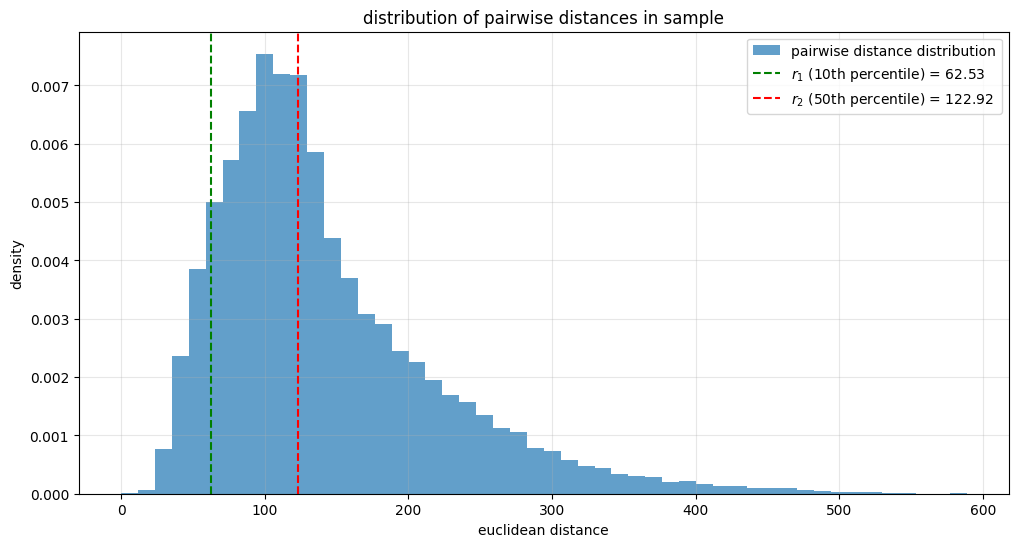


distance thresholds defined: r1=62.53, r2=122.92

--- step 2: searching for optimal 'w' ---


testing 'w' values: 100%|██████████| 40/40 [00:09<00:00,  4.00it/s]



found a practical 'w' that keeps p2 < 0.4 and maximizes p1.

observation: optimal practical parameters found
optimal bin width w = 111.824
  - corresponding p1 = 0.731
  - corresponding p2 = 0.398
  - corresponding delta = 0.341

--- step 3: visualizing tuning results ---


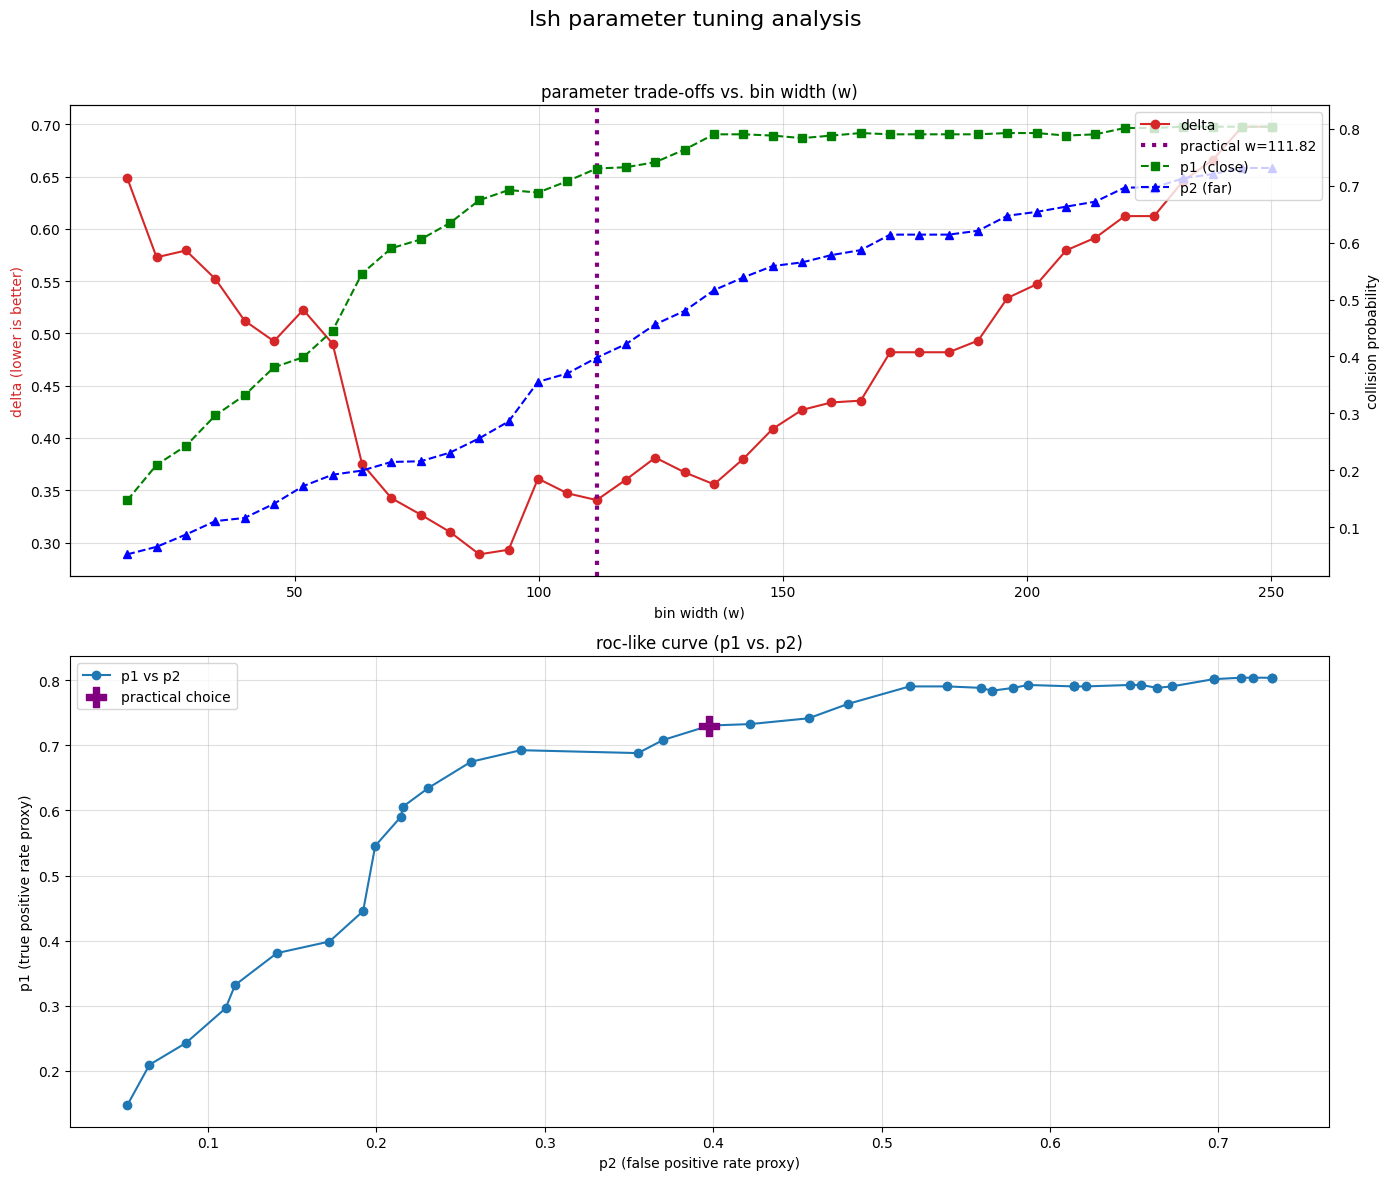


--- step 4: calculating final 'k' and 'l' ---

final recommended lsh index parameters: k=8, l=11

--- step 5: final performance evaluation ---

initializing lsh index with l=11, k=8, w=111.824...
indexing 999 points into 11 tables (vectorized)...


building lsh tables: 100%|██████████| 11/11 [00:00<00:00, 224.06it/s]


indexing complete.

evaluating precision and recall using 100 random queries...


evaluating performance: 100%|██████████| 100/100 [00:00<00:00, 5618.02it/s]


--- evaluation results ---

precision: 82.72%
recall: 28.33%


In [ ]:
# --- 1. stratified sampling and distance thresholds ---

print("\n--- step 1: defining distance thresholds via stratified sampling ---")
# stratified sampling ensures our sample is representative of all genres,
# leading to more stable estimates for r1 and r2.
sample_size_per_genre = 30
unique_labels = np.unique(labels)
sample_indices = []

for genre_id in unique_labels:
    # find all indices for the current genre.
    genre_indices = np.where(labels == genre_id)[0]
    # choose a number of samples for this genre.
    num_to_sample = min(sample_size_per_genre, len(genre_indices))
    if num_to_sample > 0:
        sample_indices.extend(np.random.choice(genre_indices, num_to_sample, replace=False))

if not sample_indices:
    print("\nerror: stratified sample is empty. cannot proceed with tuning.")
else:
    data_sample = final_dataset[sample_indices]
    print(f"\ncreated a stratified sample of {len(data_sample)} points.")

    # --- 1.1. distance distributions ---

    print(f"\ncalculating and plotting pairwise distances for the sample...")
    distances = pdist(data_sample)
    plt.figure(figsize=(12, 6))
    plt.hist(distances, bins=50, density=True, alpha=0.7, label="pairwise distance distribution")
    plt.title("distribution of pairwise distances in sample")
    plt.xlabel("euclidean distance")
    plt.ylabel("density")

    r1_percentile = 10
    r2_percentile = 50
    r1 = np.percentile(distances, r1_percentile)
    r2 = np.percentile(distances, r2_percentile)
    plt.axvline(r1, color='green', linestyle='--', label=f'$r_1$ ({r1_percentile}th percentile) = {r1:.2f}')
    plt.axvline(r2, color='red', linestyle='--', label=f'$r_2$ ({r2_percentile}th percentile) = {r2:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\ndistance thresholds defined: r1={r1:.2f}, r2={r2:.2f}")

    # --- 2. searching for the optimal bin width 'w' ---

    print("\n--- step 2: searching for optimal 'w' ---")

    def estimate_lsh_quality(w, data, r1_thresh, r2_thresh, num_test_pairs=5000, seed=42):
        input_dim = data.shape[1]
        p1_collisions, p1_total = 0, 0
        p2_collisions, p2_total = 0, 0
        hasher = EuclideanLSH(input_dim=input_dim, w=w, seed=seed)
        rng = np.random.RandomState(seed)
        for _ in range(num_test_pairs):
            p_i, p_j = data[rng.choice(len(data), 2, replace=False)]
            dist = np.linalg.norm(p_i - p_j)
            if hasher.hash(p_i) == hasher.hash(p_j):
                if dist <= r1_thresh: p1_collisions += 1
                elif dist >= r2_thresh: p2_collisions += 1
            if dist <= r1_thresh: p1_total += 1
            elif dist >= r2_thresh: p2_total += 1
        p1 = (p1_collisions / p1_total) if p1_total > 0 else 0
        p2 = (p2_collisions / p2_total) if p2_total > 0 else 0
        return p1, p2

    w_values = np.linspace(r1 / 4, r1 * 4, 40)
    tuning_results = []
    epsilon = 1e-9 # for numeric stability

    for w in tqdm(w_values, desc="testing 'w' values"):
        p1, p2 = estimate_lsh_quality(w, data_sample, r1, r2)
        # clamp probabilities for numeric stability to avoid log(0) errors.
        p1_safe = np.clip(p1, epsilon, 1 - epsilon)
        p2_safe = np.clip(p2, epsilon, 1 - epsilon)
        delta = math.log(1/p1_safe) / math.log(1/p2_safe) if p1_safe > p2_safe else float('inf')
        tuning_results.append({'w': w, 'p1': p1, 'p2': p2, 'delta': delta})

    # --- 2.1. robust selection of practical 'w' ---

    p2_threshold = 0.4
    good_candidates = [r for r in tuning_results if r['p2'] < p2_threshold]

    if good_candidates:
        best_practical = max(good_candidates, key=lambda x: x['p1'])
        print(f"\nfound a practical 'w' that keeps p2 < {p2_threshold} and maximizes p1.")
    else:
        best_practical = min(tuning_results, key=lambda x: x['p2'])
        print(f"\nwarning: could not find 'w' with p2 < {p2_threshold}. falling back to 'w' with min p2.")

    optimal_w = best_practical['w']
    best_p1 = best_practical['p1']
    best_p2 = best_practical['p2']
    min_delta = best_practical['delta']

    print("\nobservation: optimal practical parameters found")
    print(f"optimal bin width w = {optimal_w:.3f}")
    print(f"  - corresponding p1 = {best_p1:.3f}")
    print(f"  - corresponding p2 = {best_p2:.3f}")
    print(f"  - corresponding delta = {min_delta:.3f}")

    # --- 2.2. visualizations ---

    print("\n--- step 3: visualizing tuning results ---")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    fig.suptitle('lsh parameter tuning analysis', fontsize=16)

    # plot 1: delta and collision probabilities vs. w
    ax1.set_xlabel('bin width (w)')
    ax1_twin = ax1.twinx()
    ax1.plot([r['w'] for r in tuning_results], [r['delta'] for r in tuning_results], 'o-', color='tab:red', label='delta')
    ax1_twin.plot([r['w'] for r in tuning_results], [r['p1'] for r in tuning_results], 's--', color='green', label='p1 (close)')
    ax1_twin.plot([r['w'] for r in tuning_results], [r['p2'] for r in tuning_results], '^--', color='blue', label='p2 (far)')
    ax1.set_ylabel('delta (lower is better)', color='tab:red'); ax1_twin.set_ylabel('collision probability')
    ax1.axvline(optimal_w, color='purple', linestyle=':', linewidth=3, label=f'practical w={optimal_w:.2f}')
    ax1.set_title('parameter trade-offs vs. bin width (w)'); ax1.grid(True, alpha=0.4)

    # use a single legend for the top plot.
    lines, labels_ax1 = ax1.get_legend_handles_labels()
    lines_twin, labels_twin = ax1_twin.get_legend_handles_labels()
    ax1_twin.legend(lines + lines_twin, labels_ax1 + labels_twin, loc='upper right')

    # plot 2: roc-like curve (p1 vs p2)
    ax2.plot([r['p2'] for r in tuning_results], [r['p1'] for r in tuning_results], 'o-', label='p1 vs p2')
    ax2.scatter(best_p2, best_p1, marker='P', s=200, color='purple', zorder=5, label='practical choice')
    ax2.set_title('roc-like curve (p1 vs. p2)')
    ax2.set_xlabel('p2 (false positive rate proxy)')
    ax2.set_ylabel('p1 (true positive rate proxy)')
    ax2.grid(True, alpha=0.4)
    ax2.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --- 3. final evaluation ---

    print("\n--- step 4: calculating final 'k' and 'l' ---")
    k = math.ceil(math.log(m) / math.log(1/max(best_p2, epsilon)))
    L = math.ceil(m**min_delta)
    print(f"\nfinal recommended lsh index parameters: k={k}, l={L}")

    print("\n--- step 5: final performance evaluation ---")
    final_lsh_index = LSHIndex(L=L, k=k, input_dim=n_dim, w=optimal_w, seed=42)
    final_lsh_index.add_all(final_dataset)

    num_eval_queries = 100
    test_indices = np.random.choice(m, num_eval_queries, replace=False)
    query_batch = final_dataset[test_indices]
    lsh_candidates_batch = final_lsh_index.query_batch(query_batch)

    total_true_positives, total_lsh_candidates, total_true_neighbors = 0, 0, 0
    print(f"\nevaluating precision and recall using {num_eval_queries} random queries...")
    for i, query_idx in enumerate(tqdm(test_indices, desc="evaluating performance")):
        lsh_candidates = set(lsh_candidates_batch[i])
        if query_idx in lsh_candidates: lsh_candidates.remove(query_idx)
        true_neighbors = set(np.where(np.linalg.norm(final_dataset - final_dataset[query_idx], axis=1) <= r1)[0])
        if query_idx in true_neighbors: true_neighbors.remove(query_idx)
        total_true_positives += len(lsh_candidates.intersection(true_neighbors))
        total_lsh_candidates += len(lsh_candidates)
        total_true_neighbors += len(true_neighbors)

    precision = total_true_positives / total_lsh_candidates if total_lsh_candidates > 0 else 0
    recall = total_true_positives / total_true_neighbors if total_true_neighbors > 0 else 0

    print("\n--- evaluation results ---")
    print(f"\nprecision: {precision:.2%}")
    print(f"recall: {recall:.2%}")

**formulas from lectures**


--- step 1: defining distance thresholds via stratified sampling ---
created a stratified sample of 300 points.
calculating and plotting pairwise distances for the sample...


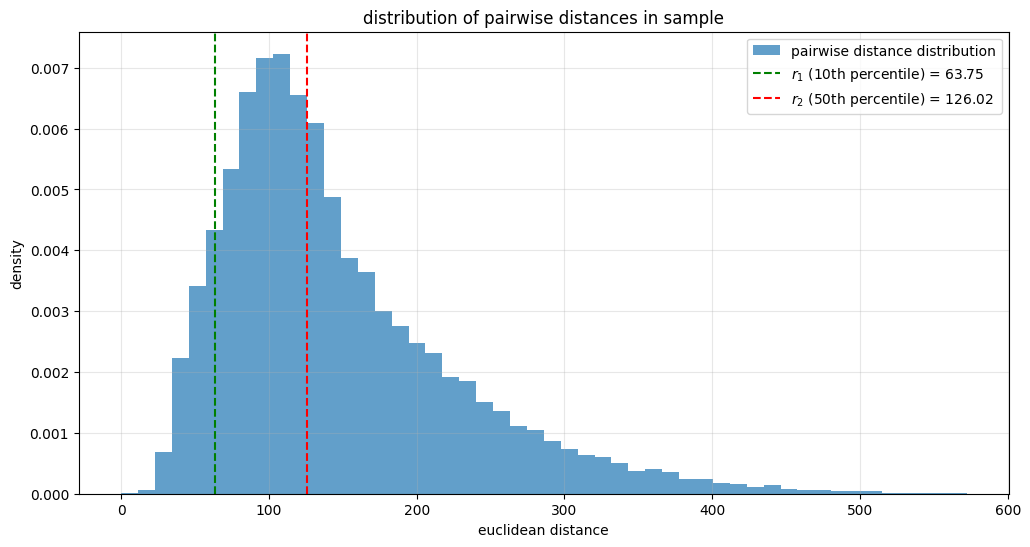

distance thresholds defined: r1=63.75, r2=126.02

--- step 2: searching for optimal 'w' ---


testing 'w' values: 100%|██████████| 40/40 [00:10<00:00,  3.96it/s]



found a practical 'w' that keeps p2 < 0.4 and maximizes p1.

observation: optimal practical parameters found
optimal bin width w = 107.890
  - corresponding p1 = 0.794
  - corresponding p2 = 0.364
  - corresponding delta = 0.229

--- step 3: visualizing tuning results ---


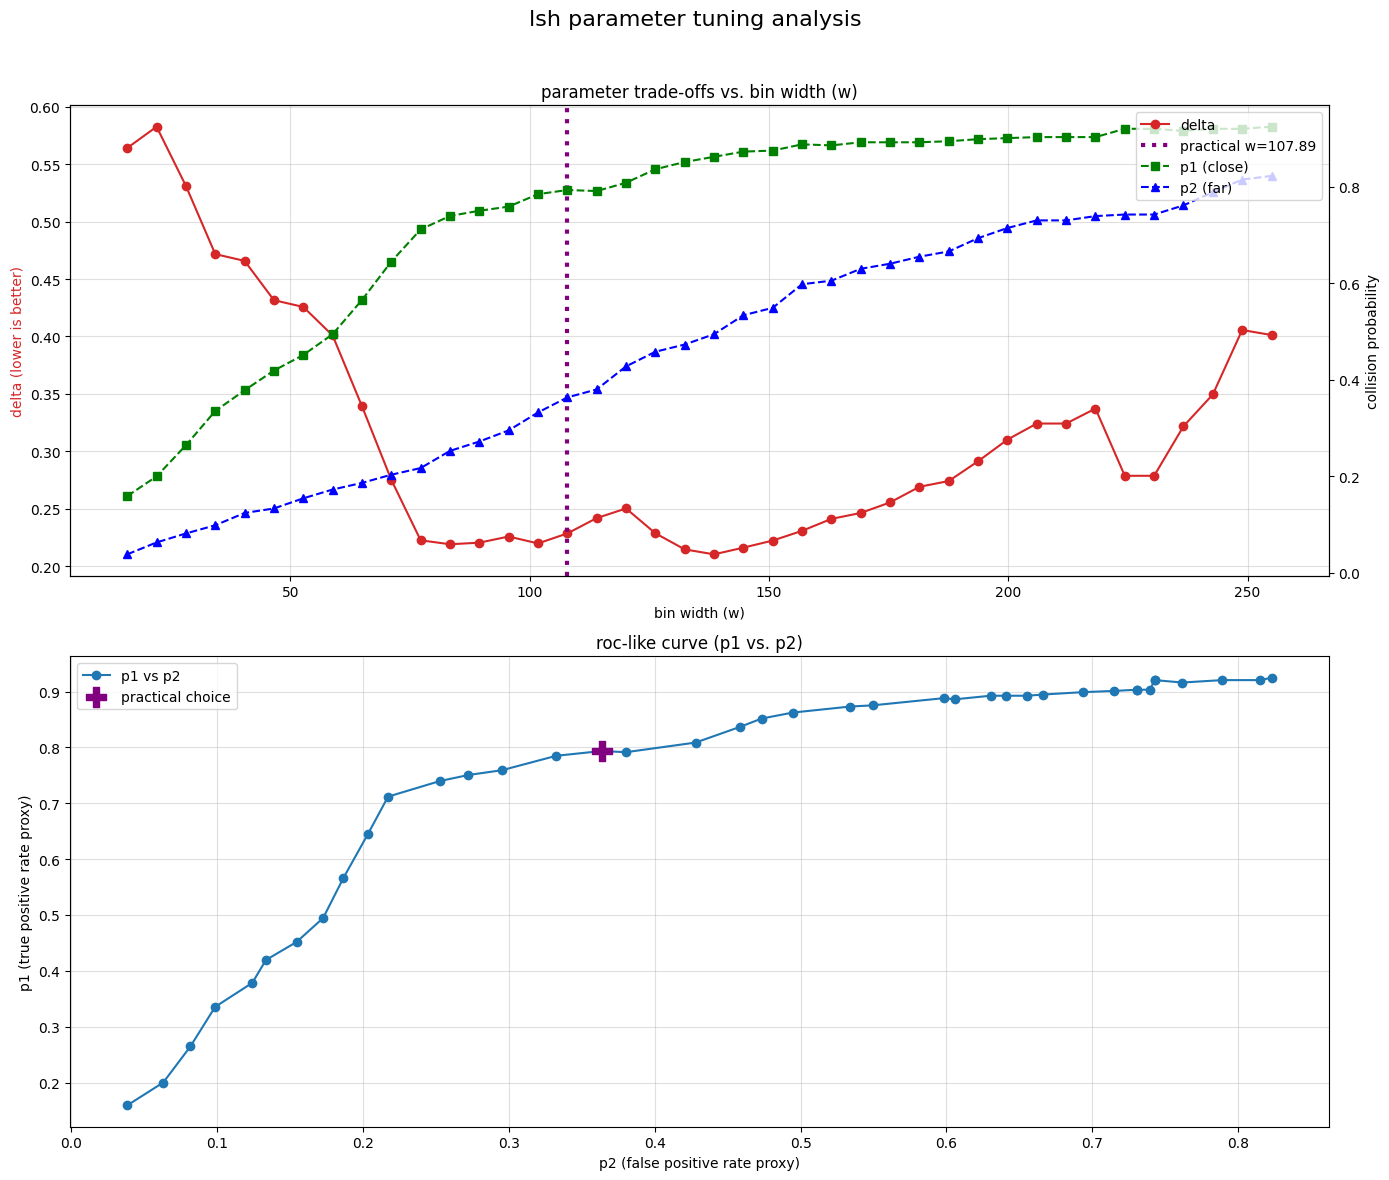


--- step 4: calculating final 'k' and 'l' ---
using a target recall of 80% to determine 'l'.
final recommended lsh index parameters: k=7, l=6

--- step 5: final performance evaluation ---

initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...


building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 218.72it/s]


indexing complete.
evaluating precision and recall using 100 random queries...


evaluating performance: 100%|██████████| 100/100 [00:00<00:00, 4617.80it/s]


--- evaluation results ---
precision: 84.08%
recall: 21.98%

--- parameter tuning and evaluation complete ---


In [ ]:
# --- 1. stratified sampling and distance thresholds ---

print("\n--- step 1: defining distance thresholds via stratified sampling ---")
# stratified sampling ensures our sample is representative of all genres,
# leading to more stable estimates for r1 and r2.
sample_size_per_genre = 30
unique_labels = np.unique(labels)
sample_indices = []

for genre_id in unique_labels:
    # find all indices for the current genre.
    genre_indices = np.where(labels == genre_id)[0]
    # choose a number of samples for this genre.
    num_to_sample = min(sample_size_per_genre, len(genre_indices))
    if num_to_sample > 0:
        sample_indices.extend(np.random.choice(genre_indices, num_to_sample, replace=False))

if not sample_indices:
    print("error: stratified sample is empty. cannot proceed with tuning.")
else:
    data_sample = final_dataset[sample_indices]
    print(f"created a stratified sample of {len(data_sample)} points.")

    # --- 1.1. distance distributions ---

    print(f"calculating and plotting pairwise distances for the sample...")
    distances = pdist(data_sample)
    plt.figure(figsize=(12, 6))
    plt.hist(distances, bins=50, density=True, alpha=0.7, label="pairwise distance distribution")
    plt.title("distribution of pairwise distances in sample")
    plt.xlabel("euclidean distance")
    plt.ylabel("density")

    r1_percentile = 10
    r2_percentile = 50
    r1 = np.percentile(distances, r1_percentile)
    r2 = np.percentile(distances, r2_percentile)
    plt.axvline(r1, color='green', linestyle='--', label=f'$r_1$ ({r1_percentile}th percentile) = {r1:.2f}')
    plt.axvline(r2, color='red', linestyle='--', label=f'$r_2$ ({r2_percentile}th percentile) = {r2:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"distance thresholds defined: r1={r1:.2f}, r2={r2:.2f}")

    # --- 2. searching for the optimal bin width 'w' ---

    print("\n--- step 2: searching for optimal 'w' ---")

    def estimate_lsh_quality(w, data, r1_thresh, r2_thresh, num_test_pairs=5000, seed=42):
        input_dim = data.shape[1]
        p1_collisions, p1_total = 0, 0
        p2_collisions, p2_total = 0, 0
        hasher = EuclideanLSH(input_dim=input_dim, w=w, seed=seed)
        rng = np.random.RandomState(seed)
        for _ in range(num_test_pairs):
            p_i, p_j = data[rng.choice(len(data), 2, replace=False)]
            dist = np.linalg.norm(p_i - p_j)
            if hasher.hash(p_i) == hasher.hash(p_j):
                if dist <= r1_thresh: p1_collisions += 1
                elif dist >= r2_thresh: p2_collisions += 1
            if dist <= r1_thresh: p1_total += 1
            elif dist >= r2_thresh: p2_total += 1
        p1 = (p1_collisions / p1_total) if p1_total > 0 else 0
        p2 = (p2_collisions / p2_total) if p2_total > 0 else 0
        return p1, p2

    w_values = np.linspace(r1 / 4, r1 * 4, 40)
    tuning_results = []
    epsilon = 1e-9 # for numeric stability

    for w in tqdm(w_values, desc="testing 'w' values"):
        p1, p2 = estimate_lsh_quality(w, data_sample, r1, r2)
        # clamp probabilities for numeric stability to avoid log(0) errors.
        p1_safe = np.clip(p1, epsilon, 1 - epsilon)
        p2_safe = np.clip(p2, epsilon, 1 - epsilon)
        delta = math.log(1/p1_safe) / math.log(1/p2_safe) if p1_safe > p2_safe else float('inf')
        tuning_results.append({'w': w, 'p1': p1, 'p2': p2, 'delta': delta})

    # --- 2.1. robust selection of practical 'w' ---

    p2_threshold = 0.4
    good_candidates = [r for r in tuning_results if r['p2'] < p2_threshold]

    if good_candidates:
        best_practical = max(good_candidates, key=lambda x: x['p1'])
        print(f"\nfound a practical 'w' that keeps p2 < {p2_threshold} and maximizes p1.")
    else:
        best_practical = min(tuning_results, key=lambda x: x['p2'])
        print(f"\nwarning: could not find 'w' with p2 < {p2_threshold}. falling back to 'w' with min p2.")

    optimal_w = best_practical['w']
    best_p1 = best_practical['p1']
    best_p2 = best_practical['p2']
    min_delta = best_practical['delta']

    print("\nobservation: optimal practical parameters found")
    print(f"optimal bin width w = {optimal_w:.3f}")
    print(f"  - corresponding p1 = {best_p1:.3f}")
    print(f"  - corresponding p2 = {best_p2:.3f}")
    print(f"  - corresponding delta = {min_delta:.3f}")

    # --- 2.2. visualizations ---

    print("\n--- step 3: visualizing tuning results ---")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    fig.suptitle('lsh parameter tuning analysis', fontsize=16)

    # plot 1: delta and collision probabilities vs. w
    ax1.set_xlabel('bin width (w)')
    ax1_twin = ax1.twinx()
    ax1.plot([r['w'] for r in tuning_results], [r['delta'] for r in tuning_results], 'o-', color='tab:red', label='delta')
    ax1_twin.plot([r['w'] for r in tuning_results], [r['p1'] for r in tuning_results], 's--', color='green', label='p1 (close)')
    ax1_twin.plot([r['w'] for r in tuning_results], [r['p2'] for r in tuning_results], '^--', color='blue', label='p2 (far)')
    ax1.set_ylabel('delta (lower is better)', color='tab:red'); ax1_twin.set_ylabel('collision probability')
    ax1.axvline(optimal_w, color='purple', linestyle=':', linewidth=3, label=f'practical w={optimal_w:.2f}')
    ax1.set_title('parameter trade-offs vs. bin width (w)'); ax1.grid(True, alpha=0.4)

    # use a single legend for the top plot.
    lines, labels_ax1 = ax1.get_legend_handles_labels()
    lines_twin, labels_twin = ax1_twin.get_legend_handles_labels()
    ax1_twin.legend(lines + lines_twin, labels_ax1 + labels_twin, loc='upper right')

    # plot 2: roc-like curve (p1 vs p2)
    ax2.plot([r['p2'] for r in tuning_results], [r['p1'] for r in tuning_results], 'o-', label='p1 vs p2')
    ax2.scatter(best_p2, best_p1, marker='P', s=200, color='purple', zorder=5, label='practical choice')
    ax2.set_title('roc-like curve (p1 vs. p2)')
    ax2.set_xlabel('p2 (false positive rate proxy)')
    ax2.set_ylabel('p1 (true positive rate proxy)')
    ax2.grid(True, alpha=0.4)
    ax2.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --- 3. final evaluation ---

    print("\n--- step 4: calculating final 'k' and 'l' ---")

    # new: add a target recall parameter to explicitly tune for it.
    target_recall = 0.80 # let's aim for 80% recall.
    print(f"using a target recall of {target_recall:.0%} to determine 'l'.")

    # calculate theta from the target recall (tpr) using your formula: tpr = 1 - e^-theta
    # this implies: theta = -log(1 - tpr)
    if target_recall >= 1.0:
        theta = float('inf')
    else:
        theta = -math.log(1 - target_recall)

    # calculate k using the standard formula.
    k = math.ceil(math.log(m) / math.log(1/max(best_p2, epsilon)))

    # calculate l using your new theta-based formula: l = (theta * n)^delta
    # we use 'm' for the number of points, as defined in the script.
    # this provides more explicit control over the recall-precision trade-off.
    if theta == float('inf'):
        L = float('inf') # or a very large number, representing near-perfect recall
    else:
        L = math.ceil((theta * m)**min_delta)

    print(f"final recommended lsh index parameters: k={k}, l={L}")

    print("\n--- step 5: final performance evaluation ---")
    # handle the case where l could be extremely large.
    if L > 500: # set a practical upper limit for l to avoid memory issues.
        print(f"warning: calculated l={L} is very large. capping at 500 for this evaluation.")
        L = 500

    final_lsh_index = LSHIndex(L=L, k=k, input_dim=n_dim, w=optimal_w, seed=42)
    final_lsh_index.add_all(final_dataset)

    num_eval_queries = 100
    test_indices = np.random.choice(m, num_eval_queries, replace=False)
    query_batch = final_dataset[test_indices]
    lsh_candidates_batch = final_lsh_index.query_batch(query_batch)

    total_true_positives, total_lsh_candidates, total_true_neighbors = 0, 0, 0
    print(f"evaluating precision and recall using {num_eval_queries} random queries...")
    for i, query_idx in enumerate(tqdm(test_indices, desc="evaluating performance")):
        lsh_candidates = set(lsh_candidates_batch[i])
        if query_idx in lsh_candidates: lsh_candidates.remove(query_idx)
        true_neighbors = set(np.where(np.linalg.norm(final_dataset - final_dataset[query_idx], axis=1) <= r1)[0])
        if query_idx in true_neighbors: true_neighbors.remove(query_idx)
        total_true_positives += len(lsh_candidates.intersection(true_neighbors))
        total_lsh_candidates += len(lsh_candidates)
        total_true_neighbors += len(true_neighbors)

    precision = total_true_positives / total_lsh_candidates if total_lsh_candidates > 0 else 0
    recall = total_true_positives / total_true_neighbors if total_true_neighbors > 0 else 0

    print("\n--- evaluation results ---")
    print(f"precision: {precision:.2%}")
    print(f"recall: {recall:.2%}")
    print("\n--- parameter tuning and evaluation complete ---")

# Q8. Comparing LSH and Brute Force Nearest Neighbors

In [ ]:
import numpy as np
import time
from tqdm import tqdm
import pandas as pd

In [ ]:
# --- prerequisite check ---

# this script assumes that 'final_dataset', 'final_lsh_index', 'r1', 'k',
# and 'L' are all available from the previous parts.
if 'final_lsh_index' not in globals() or 'r1' not in globals():
    print("error: prerequisite variables or classes not found.")
    print("please ensure parts 1, 2, and 3 have been executed successfully.")
    # as a fallback for standalone execution, create placeholder variables.
    if 'final_dataset' not in globals(): final_dataset = np.random.rand(999, 40)
    if 'LSHIndex' not in globals():
        from collections import defaultdict
        class EuclideanLSH:
            def __init__(self, i, w, s): self.w,self.v,self.b = w,np.random.RandomState(s).randn(i),np.random.RandomState(s).uniform(0,w)
            def hash(self, p): return int(np.floor((np.dot(p, self.v) + self.b) / self.w))
        class LSHTable:
            def __init__(self, k, i, w, s):
                rng=np.random.RandomState(s);h=rng.randint(0,1_000_000,k);self.v=np.array([EuclideanLSH(i,w,s).v for s in h]).T;self.b=np.array([EuclideanLSH(i,w,s).b for s in h]);self.w=w;self.table=defaultdict(list)
            def add_all(self, d):
                h=np.floor((d@self.v+self.b)/self.w).astype(int);[self.table[tuple(k)].append(i) for i,k in enumerate(h)]
            def query_batch(self, p):
                h=np.floor((p@self.v+self.b)/self.w).astype(int);return [self.table.get(tuple(k),[]) for k in h]
        class LSHIndex:
            def __init__(self,L,k,i,w,s=42):
                rng=np.random.RandomState(s);t=rng.randint(0,1_000_000,L);self.tables=[LSHTable(k,i,w,s) for s in t]
            def add_all(self,d): [t.add_all(d) for t in self.tables]
            def query_batch(self,p):
                c=[set() for _ in range(p.shape[0])];[c[i].update(b) for t in self.tables for i,b in enumerate(t.query_batch(p))];return [list(s) for s in c]
    # create placeholder values if they don't exist
    final_lsh_index = LSHIndex(L=10, k=10, input_dim=40, w=100.0)
    final_lsh_index.add_all(final_dataset)
    r1 = 65.0

m, n_dim = final_dataset.shape
print("--- comparing lsh vs. brute force ---")
print(f"dataset dimensions loaded: m={m}, n={n_dim}")

--- comparing lsh vs. brute force ---
dataset dimensions loaded: m=999, n=40


In [ ]:
# --- 1. brute-force nearest neighbor implementation ---

def brute_force_knn(query_point, data, K):
    """
    finds the K nearest neighbors to a query point using brute-force search.

    returns:
        a sorted list of tuples (distance, point_id).
    """
    # calculate the euclidean distance from the query point to all other points.
    distances = np.linalg.norm(data - query_point, axis=1)

    # get the indices of the K smallest distances.
    # we use `np.argpartition` because it's faster than a full sort if we only
    # need the top K elements. we ask for K+1 to exclude the point itself.
    nearest_indices = np.argpartition(distances, K + 1)[:K + 1]

    # create a list of (distance, index) tuples for the nearest neighbors.
    results = sorted([(distances[i], i) for i in nearest_indices])

    # exclude the query point itself (which will have a distance of 0).
    return results[1:]

In [ ]:
# --- 2. performance scaling experiment ---

# select at least six dataset sizes to test.
n_samples_list = [100, 200, 400, 600, 800, m]
num_trials = 10 # number of times to sample for each dataset size to get stable stats.
K_for_timing = 10 # number of neighbors for brute-force search.

# lists to store the results for plotting.
avg_lsh_times, std_lsh_times = [], []
avg_bf_times, std_bf_times = [], []

for n_i in tqdm(n_samples_list, desc="testing dataset sizes"):
    lsh_trial_times, bf_trial_times = [], []

    for _ in range(num_trials):
        # create a dataset by randomly selecting n_i rows.
        subset_indices = np.random.choice(m, n_i, replace=False)
        data_subset = final_dataset[subset_indices]

        # --- time lsh ---
        # 1. build a new lsh index for this subset.
        # we use the same k, l, w parameters tuned for the full dataset.
        lsh_index_subset = LSHIndex(L=L, k=k, input_dim=n_dim, w=optimal_w, seed=42)
        lsh_index_subset.add_all(data_subset)

        # 2. select a random query point from the subset.
        query_point = data_subset[np.random.choice(n_i, 1)]

        # 3. time the query.
        start_time = time.time()
        lsh_index_subset.query_batch(query_point)
        lsh_trial_times.append(time.time() - start_time)

        # --- time brute force ---
        start_time = time.time()
        brute_force_knn(query_point[0], data_subset, K_for_timing)
        bf_trial_times.append(time.time() - start_time)

    # calculate average and standard deviation for this dataset size.
    avg_lsh_times.append(np.mean(lsh_trial_times))
    std_lsh_times.append(np.std(lsh_trial_times))
    avg_bf_times.append(np.mean(bf_trial_times))
    std_bf_times.append(np.std(bf_trial_times))

testing dataset sizes:   0%|          | 0/6 [00:00<?, ?it/s]


initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 1552.97it/s]


indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 1315.86it/s]


...

indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 410.22it/s]


indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...



testing dataset sizes: 100%|██████████| 6/6 [00:03<00:00,  1.90it/s]

indexing complete.


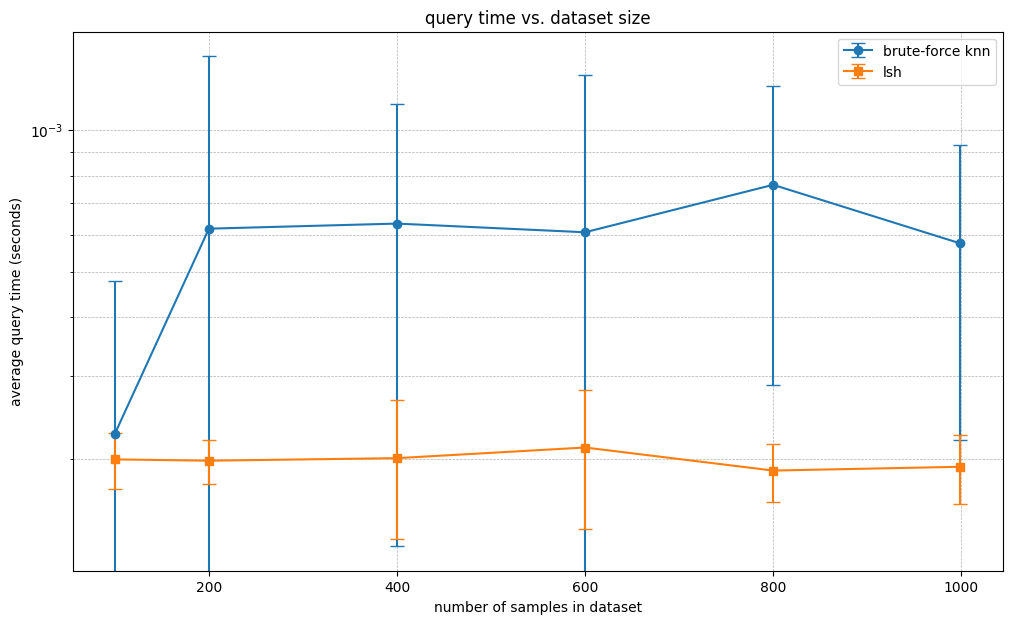

In [ ]:
# --- 3. plotting the scaling results ---

plt.figure(figsize=(12, 7))
plt.errorbar(n_samples_list, avg_bf_times, yerr=std_bf_times, fmt='-o',
             label='brute-force knn', capsize=5)
plt.errorbar(n_samples_list, avg_lsh_times, yerr=std_lsh_times, fmt='-s',
             label='lsh', capsize=5)

plt.title('query time vs. dataset size')
plt.xlabel('number of samples in dataset')
plt.ylabel('average query time (seconds)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log') # use a log scale for y-axis to better visualize differences.
plt.show()

In [ ]:
# Method 2

def brute_force_knn(query_point, data, K):
    """finds the k nearest neighbors to a query point using brute-force search."""
    distances = np.linalg.norm(data - query_point, axis=1)
    nearest_indices = np.argpartition(distances, K + 1)[:K + 1]
    results = sorted([(distances[i], i) for i in nearest_indices])
    return results[1:]

def get_true_neighbors(query_point, data, radius):
    """finds all points within a given radius of the query point."""
    distances = np.linalg.norm(data - query_point, axis=1)
    return set(np.where(distances <= radius)[0])


n_samples_list = [100, 200, 400, 600, 800, m]
num_trials = 10
K_for_timing = 10
results_data = []

for n_i in tqdm(n_samples_list, desc="testing dataset sizes"):
    lsh_trial_times, bf_trial_times, recall_trials, candidates_trials = [], [], [], []

    for _ in range(num_trials):
        subset_indices = np.random.choice(m, n_i, replace=False)
        data_subset = final_dataset[subset_indices]

        query_idx_in_subset = np.random.choice(n_i)
        query_point_subset = data_subset[query_idx_in_subset]

        # --- time and evaluate lsh ---
        lsh_index_subset = LSHIndex(L=L, k=k, input_dim=n_dim, w=optimal_w, seed=42)
        lsh_index_subset.add_all(data_subset)

        start_time = time.time()
        lsh_candidates = set(lsh_index_subset.query_batch(np.array([query_point_subset]))[0])
        lsh_trial_times.append(time.time() - start_time)

        if query_idx_in_subset in lsh_candidates:
            lsh_candidates.remove(query_idx_in_subset)

        candidates_trials.append(len(lsh_candidates))

        # --- time and evaluate brute force ---
        start_time = time.time()
        brute_force_knn(query_point_subset, data_subset, K_for_timing)
        bf_trial_times.append(time.time() - start_time)

        # --- calculate recall for this trial ---
        true_neighbors = get_true_neighbors(query_point_subset, data_subset, r1)
        if query_idx_in_subset in true_neighbors:
            true_neighbors.remove(query_idx_in_subset)

        if len(true_neighbors) > 0:
            recall = len(lsh_candidates.intersection(true_neighbors)) / len(true_neighbors)
            recall_trials.append(recall)

    # store the average and standard deviation for all metrics
    results_data.append({
        "n_samples": n_i,
        "avg_lsh_time": np.mean(lsh_trial_times),
        "std_lsh_time": np.std(lsh_trial_times),
        "avg_bf_time": np.mean(bf_trial_times),
        "std_bf_time": np.std(bf_trial_times),
        "avg_recall": np.mean(recall_trials) if recall_trials else 0,
        "std_recall": np.std(recall_trials) if recall_trials else 0,
        "avg_candidates": np.mean(candidates_trials)
    })

results_df = pd.DataFrame(results_data)
results_df['speedup_factor'] = results_df['avg_bf_time'] / results_df['avg_lsh_time']

testing dataset sizes:   0%|          | 0/6 [00:00<?, ?it/s]


initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 1752.62it/s]


indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 2009.89it/s]


...


building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 300.25it/s]

indexing complete.



initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...



testing dataset sizes: 100%|██████████| 6/6 [00:02<00:00,  2.23it/s]

indexing complete.



--- step 2: plotting performance scaling ---


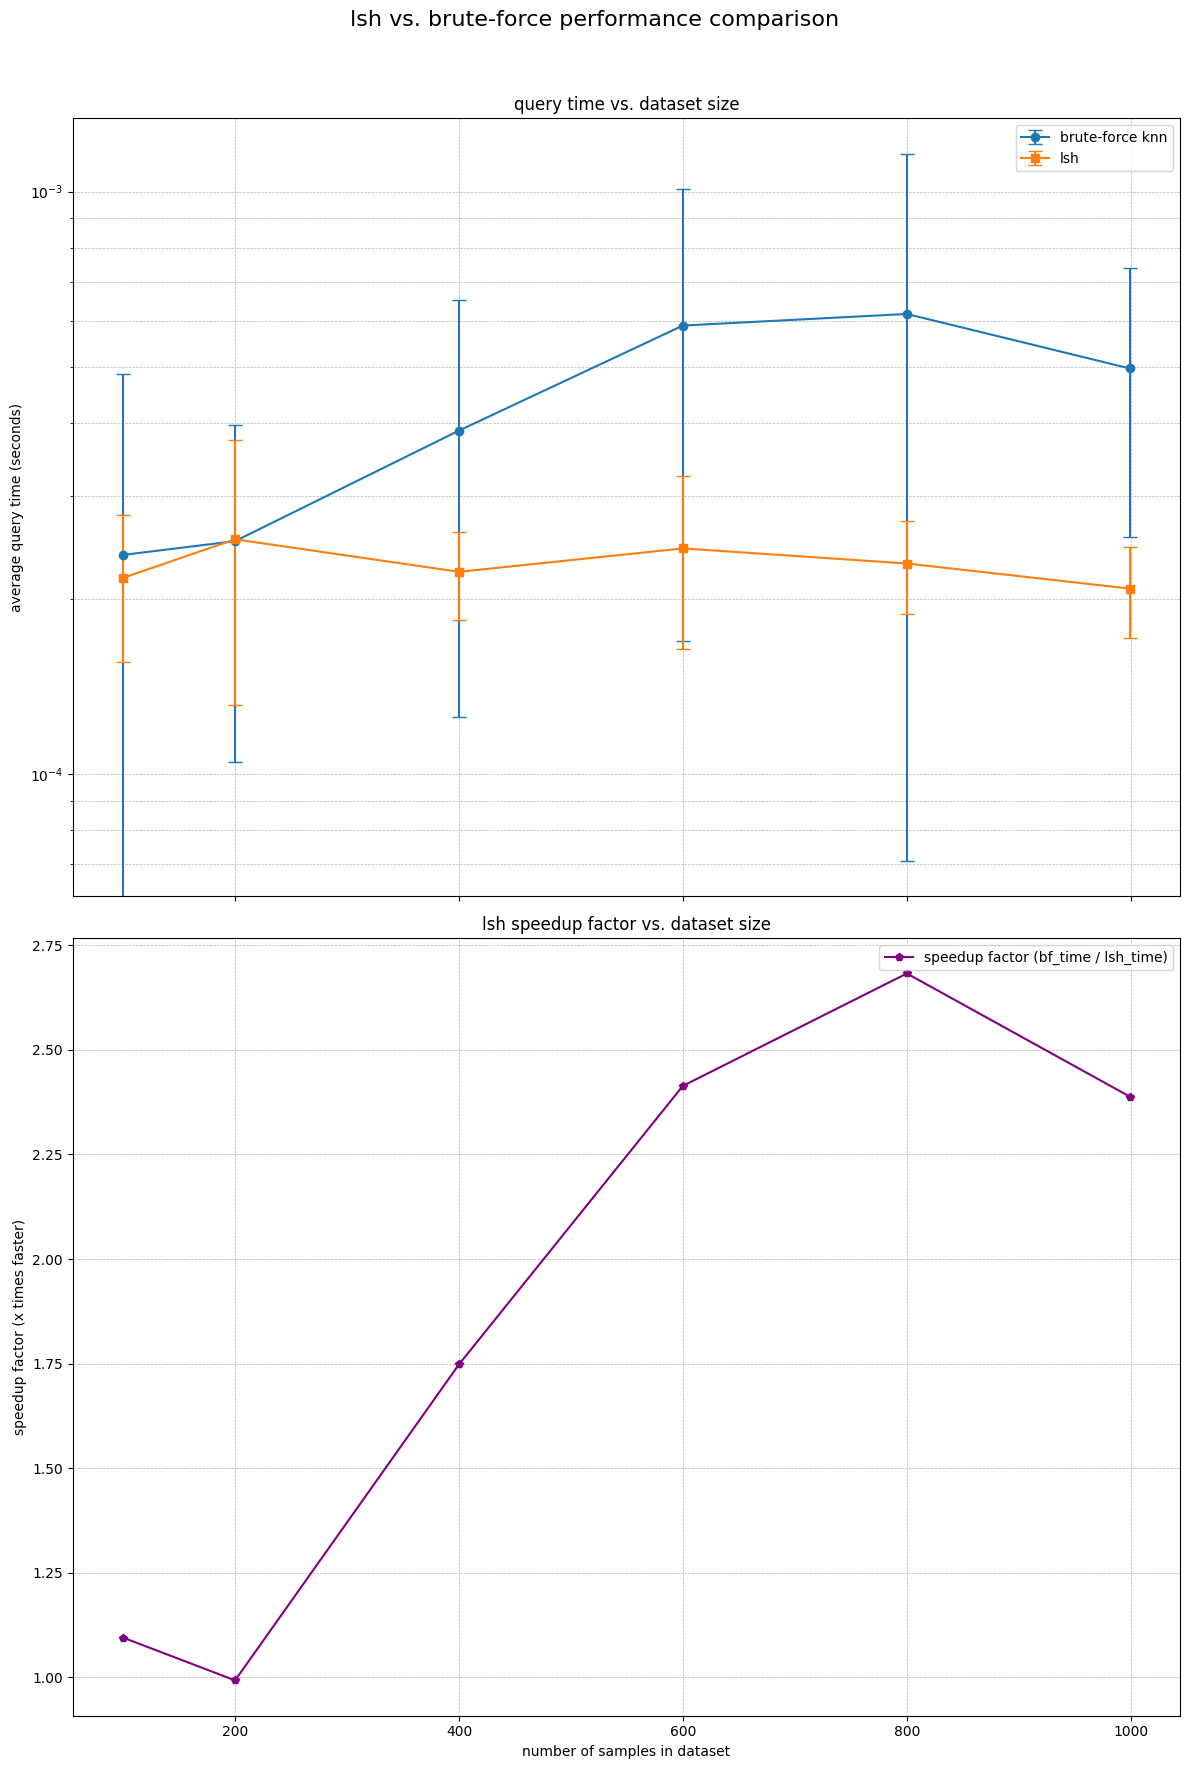

In [ ]:
# --- 3. plotting the scaling results ---

print("\n--- step 2: plotting performance scaling ---")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 18), sharex=True)
fig.suptitle('lsh vs. brute-force performance comparison', fontsize=16)

# plot 1: query time vs. dataset size
ax1.errorbar(results_df['n_samples'], results_df['avg_bf_time'], yerr=results_df['std_bf_time'],
             fmt='-o', label='brute-force knn', capsize=5)
ax1.errorbar(results_df['n_samples'], results_df['avg_lsh_time'], yerr=results_df['std_lsh_time'],
             fmt='-s', label='lsh', capsize=5)
ax1.set_ylabel('average query time (seconds)')
ax1.set_title('query time vs. dataset size')
ax1.set_yscale('log')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend()

# plot 2: speedup factor vs. dataset size
ax2.plot(results_df['n_samples'], results_df['speedup_factor'], '-p',
         label='speedup factor (bf_time / lsh_time)', color='purple')
ax2.set_xlabel('number of samples in dataset')
ax2.set_ylabel('speedup factor (x times faster)')
ax2.set_title('lsh speedup factor vs. dataset size')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# --- 4. summary table and final observations ---
print("\n--- step 3: summary of results ---")
# format for printing the table
pd.options.display.float_format = '{:.4f}'.format
print(results_df[['n_samples', 'avg_bf_time', 'avg_lsh_time', 'speedup_factor', 'avg_recall', 'avg_candidates']].to_string(index=False))


--- step 3: summary of results ---
 n_samples  avg_bf_time  avg_lsh_time  speedup_factor  avg_recall  avg_candidates
       100       0.0002        0.0002          0.9628      0.2429          3.3000
       200       0.0004        0.0002          2.2547      0.2813          6.0000
       400       0.0007        0.0002          4.1210      0.2567          7.2000
       600       0.0005        0.0002          2.3442      0.1738         13.4000
       800       0.0005        0.0002          2.6077      0.1791         17.2000
       999       0.0010        0.0002          5.0117      0.2640         33.1000


# Q9. Evaluating LSH Precision

In [ ]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# --- prerequisite check ---

# this script assumes that 'final_dataset', 'labels', 'r1', 'k', 'l',
# and 'optimal_w' are all available from the previous parts.
if 'final_dataset' not in globals() or 'labels' not in globals() or 'r1' not in globals():
    print("error: prerequisite variables not found.")
    print("please ensure parts 1, 2, and 3 have been executed successfully.")
    # as a fallback for standalone execution, create placeholder variables.
    if 'final_dataset' not in globals(): final_dataset = np.random.rand(999, 40)
    if 'LSHIndex' not in globals():
        from collections import defaultdict
        class EuclideanLSH:
            def __init__(self, i, w, s): self.w,self.v,self.b = w,np.random.RandomState(s).randn(i),np.random.RandomState(s).uniform(0,w)
            def hash(self, p): return int(np.floor((np.dot(p, self.v) + self.b) / self.w))
        class LSHTable:
            def __init__(self, k, i, w, s):
                rng=np.random.RandomState(s);h=rng.randint(0,1_000_000,k);self.v=np.array([EuclideanLSH(i,w,s).v for s in h]).T;self.b=np.array([EuclideanLSH(i,w,s).b for s in h]);self.w=w;self.table=defaultdict(list)
            def add_all(self, d):
                h=np.floor((d@self.v+self.b)/self.w).astype(int);[self.table[tuple(k)].append(i) for i,k in enumerate(h)]
            def query_batch(self, p):
                h=np.floor((p@self.v+self.b)/self.w).astype(int);return [self.table.get(tuple(k),[]) for k in h]
        class LSHIndex:
            def __init__(self,L,k,i,w,s=42):
                rng=np.random.RandomState(s);t=rng.randint(0,1_000_000,L);self.tables=[LSHTable(k,i,w,s) for s in t]
            def add_all(self,d): [t.add_all(d) for t in self.tables]
            def query_batch(self,p):
                c=[set() for _ in range(p.shape[0])];[c[i].update(b) for t in self.tables for i,b in enumerate(t.query_batch(p))];return [list(s) for s in c]
    # create placeholder values if they don't exist
    k, L, optimal_w, r1 = 10, 10, 100.0, 65.0

m, n_dim = final_dataset.shape
print("--- comparing lsh vs. brute force ---")
print(f"dataset dimensions loaded: m={m}, n={n_dim}")

--- comparing lsh vs. brute force ---
dataset dimensions loaded: m=999, n=40


In [ ]:
# --- 1. brute-force nearest neighbor implementation ---

def brute_force_knn(query_point, data, K):
    """finds the k nearest neighbors to a query point using brute-force search."""
    distances = np.linalg.norm(data - query_point, axis=1)
    # find the indices of the k+1 smallest distances to account for the query point itself.
    nearest_indices = np.argpartition(distances, K + 1)[:K + 1]
    # create a list of (distance, index) tuples.
    results = sorted([(distances[i], i) for i in nearest_indices])
    # return the top k, excluding the query point itself.
    return results[1:]

def get_true_neighbors_radius(query_point, data, radius):
    """finds all points within a given radius of the query point."""
    distances = np.linalg.norm(data - query_point, axis=1)
    return set(np.where(distances <= radius)[0])

In [ ]:
# --- 2. performance scaling experiment ---

print("\n--- step 1: evaluating query performance vs. dataset size ---")

n_samples_list = [100, 200, 400, 600, 800, m]
num_trials = 10
K_for_eval = 10 # we will evaluate precision for the top 10 neighbors.
results_data = []

for n_i in tqdm(n_samples_list, desc="testing dataset sizes"):
    lsh_trial_times, bf_trial_times, recall_trials, candidates_trials, precision_at_10_trials = [], [], [], [], []

    for _ in range(num_trials):
        subset_indices = np.random.choice(m, n_i, replace=False)
        data_subset = final_dataset[subset_indices]

        query_idx_in_subset = np.random.choice(n_i)
        query_point_subset = data_subset[query_idx_in_subset]

        # --- time and evaluate lsh ---
        lsh_index_subset = LSHIndex(L=L, k=k, input_dim=n_dim, w=optimal_w, seed=42)
        lsh_index_subset.add_all(data_subset)

        start_time = time.time()
        lsh_candidates = set(lsh_index_subset.query_batch(np.array([query_point_subset]))[0])
        lsh_trial_times.append(time.time() - start_time)

        if query_idx_in_subset in lsh_candidates:
            lsh_candidates.remove(query_idx_in_subset)

        candidates_trials.append(len(lsh_candidates))

        # --- time brute force ---
        start_time = time.time()
        # get the true top k neighbors for precision calculation.
        true_top_k_neighbors = {idx for dist, idx in brute_force_knn(query_point_subset, data_subset, K_for_eval)}
        bf_trial_times.append(time.time() - start_time)

        # --- calculate recall (radius-based) for this trial ---
        true_radius_neighbors = get_true_neighbors_radius(query_point_subset, data_subset, r1)
        if query_idx_in_subset in true_radius_neighbors:
            true_radius_neighbors.remove(query_idx_in_subset)

        if len(true_radius_neighbors) > 0:
            recall = len(lsh_candidates.intersection(true_radius_neighbors)) / len(true_radius_neighbors)
            recall_trials.append(recall)

        # --- calculate precision@10 for this trial ---
        # this measures what proportion of the true top 10 neighbors were found by lsh.
        if K_for_eval > 0:
            precision_at_10 = len(lsh_candidates.intersection(true_top_k_neighbors)) / K_for_eval
            precision_at_10_trials.append(precision_at_10)

    # store the average and standard deviation for all metrics
    results_data.append({
        "n_samples": n_i,
        "avg_lsh_time": np.mean(lsh_trial_times),
        "std_lsh_time": np.std(lsh_trial_times),
        "avg_bf_time": np.mean(bf_trial_times),
        "std_bf_time": np.std(bf_trial_times),
        "avg_recall_radius": np.mean(recall_trials) if recall_trials else 0,
        "std_recall_radius": np.std(recall_trials) if recall_trials else 0,
        "avg_precision_at_10": np.mean(precision_at_10_trials) if precision_at_10_trials else 0,
        "std_precision_at_10": np.std(precision_at_10_trials) if precision_at_10_trials else 0,
        "avg_candidates": np.mean(candidates_trials)
    })

results_df = pd.DataFrame(results_data)
results_df['speedup_factor'] = results_df['avg_bf_time'] / results_df['avg_lsh_time']


--- step 1: evaluating query performance vs. dataset size ---


testing dataset sizes:   0%|          | 0/6 [00:00<?, ?it/s]


initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 3680.29it/s]


indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 100 points into 6 tables (vectorized)...


...

indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...



building lsh tables: 100%|██████████| 6/6 [00:00<00:00, 334.63it/s]


indexing complete.

initializing lsh index with l=6, k=7, w=107.890...
indexing 999 points into 6 tables (vectorized)...



testing dataset sizes: 100%|██████████| 6/6 [00:02<00:00,  2.25it/s]

indexing complete.



--- step 2: plotting performance scaling ---


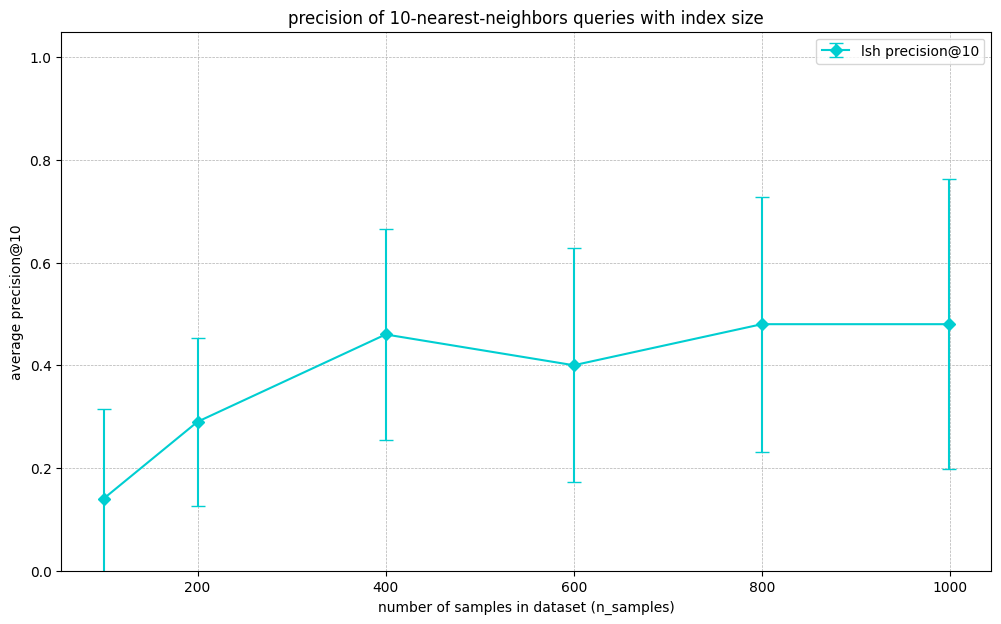

In [ ]:
# --- 3. plotting the scaling results ---
print("\n--- step 2: plotting performance scaling ---")
plt.figure(figsize=(12, 7))
plt.errorbar(results_df['n_samples'], results_df['avg_precision_at_10'], yerr=results_df['std_precision_at_10'],
             fmt='-D', label='lsh precision@10', capsize=5, color='darkturquoise')
plt.ylabel('average precision@10')
plt.xlabel('number of samples in dataset (n_samples)')
plt.title('precision of 10-nearest-neighbors queries with index size')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [ ]:
# --- 4. summary table and final observations ---
print("\n--- step 3: summary of results ---")
# format for printing the table
pd.options.display.float_format = '{:.4f}'.format
print(results_df[['n_samples', 'avg_bf_time', 'avg_lsh_time', 'speedup_factor', 'avg_recall_radius', 'avg_precision_at_10', 'avg_candidates']].to_string(index=False))


--- step 3: summary of results ---
 n_samples  avg_bf_time  avg_lsh_time  speedup_factor  avg_recall_radius  avg_precision_at_10  avg_candidates
       100       0.0007        0.0002          3.3551             0.1753               0.1400          1.9000
       200       0.0004        0.0002          1.8858             0.1992               0.2900          4.7000
       400       0.0006        0.0002          3.1209             0.1789               0.4600         10.8000
       600       0.0005        0.0002          2.5883             0.1767               0.4000          9.6000
       800       0.0007        0.0002          3.1156             0.1771               0.4800         24.3000
       999       0.0005        0.0002          2.3430             0.2056               0.4800         27.2000


# ------------------------------------------------------------------------------

# Randomized SVD

# Q10. Power-iteration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. generate the random matrix ---

# for reproducibility, we set a random seed.
np.random.seed(42)

# generate a random matrix a of shape (100, 100) with entries
# drawn from a standard normal distribution n(0, 1).
A = np.random.randn(100, 100)

In [ ]:
# --- 2. compute svd for different power iterations (q) ---

# we will test q from 0 to 5.
q_values = range(6)
all_singular_values = {}

print("observation: computing svd for (a @ a.t)**q @ a for q in {0, 1, 2, 3, 4, 5}...")

for q in q_values:
    # calculate the matrix (a @ a.t).
    AAT = A @ A.T

    # raise (a @ a.t) to the power of q.
    # np.linalg.matrix_power is the correct way to compute matrix powers.
    AAT_q = np.linalg.matrix_power(AAT, q)

    # compute the final matrix b_q = (a @ a.t)**q @ a.
    B_q = AAT_q @ A

    # compute the singular values of b_q. we don't need the u and v vectors,
    # so we can set compute_uv=false for a slight performance gain.
    s = np.linalg.svd(B_q, compute_uv=False)

    # store the singular values for this q.
    all_singular_values[q] = s

observation: computing svd for (a @ a.t)**q @ a for q in {0, 1, 2, 3, 4, 5}...


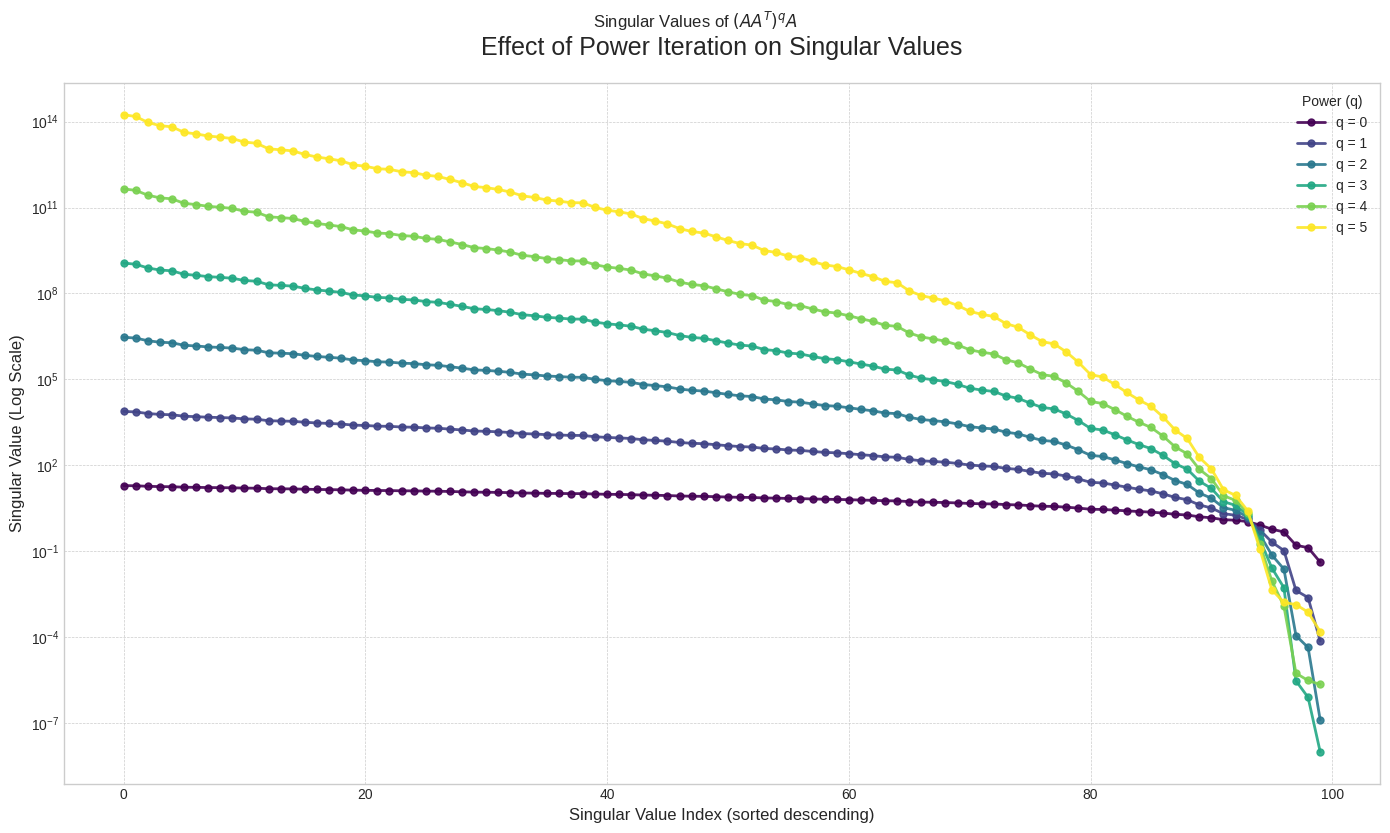

In [ ]:
# --- 3. plot the singular values ---

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 9))

# use a sequential colormap to show the progression of q.
# this maps each value of q to a distinct color in the sequence.
colors = plt.cm.viridis(np.linspace(0, 1, len(q_values)))

for i, q in enumerate(q_values):
    plt.plot(all_singular_values[q],
             'o-',
             label=f'q = {q}',
             color=colors[i],
             linewidth=2,
             markersize=5,
             alpha=0.9)

plt.yscale('log')

plt.title('Effect of Power Iteration on Singular Values', fontsize=18, pad=20)
plt.suptitle('Singular Values of $(A A^T)^q A$', fontsize=12, y=0.92)
plt.xlabel('Singular Value Index (sorted descending)', fontsize=12)
plt.ylabel('Singular Value (Log Scale)', fontsize=12)
plt.legend(title="Power (q)", fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Q11. PCA

In [ ]:
# !pip install kagglehub scikit-learn pillow
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
from sklearn.decomposition import PCA
from tqdm import tqdm

In [ ]:
# --- 1. download and prepare the dataset ---

data_dir = "/content/human_faces_data"
# the kaggle dataset has a nested structure, so we point to the actual image folder.
faces_folder = os.path.join(data_dir, "Humans")

# check if the dataset already exists to avoid re-downloading.
if not os.path.exists(faces_folder):
    print("dataset not found locally. downloading from kaggle...")
    # download returns a path to the downloaded content.
    try:
        archive_path = kagglehub.dataset_download("ashwingupta3012/human-faces")
        print(f"dataset downloaded to: {archive_path}")
        # copy the dataset to our desired structured directory.
        shutil.copytree(archive_path, data_dir, dirs_exist_ok=True)
        print("dataset prepared successfully.")
    except Exception as e:
        print(f"error downloading or preparing dataset: {e}")
        print("please ensure you are authenticated with kaggle.")
        exit()
else:
    print("observation: dataset already exists locally.")

observation: dataset already exists locally.


In [ ]:
# --- 2. load and preprocess images ---

image_size = (100, 100)
image_vectors = []

# get a list of all image files.
image_files = [f for f in os.listdir(faces_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for file_name in tqdm(image_files, desc="processing images"):
    try:
        file_path = os.path.join(faces_folder, file_name)
        # open image, convert to grayscale.
        img = Image.open(file_path).convert('L')
        # resize the image.
        img = img.resize(image_size)
        # convert to numpy array and scale pixel values to [0, 1].
        img_array = np.array(img) / 255.0
        # flatten the 100x100 image into a 10000-element vector and add to list.
        image_vectors.append(img_array.flatten())
    except Exception as e:
        print(f"warning: could not process file {file_name}. error: {e}")

# stack all vectors into a single data matrix.
# each row is a flattened image.
X = np.array(image_vectors)
print(f"\ncreated data matrix x with shape: {X.shape}")

processing images:   8%|▊         | 593/7219 [00:15<01:45, 62.84it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
processing images: 100%|██████████| 7219/7219 [03:21<00:00, 35.88it/s]



created data matrix x with shape: (7219, 10000)


In [ ]:
# --- 3. center the dataset ---

# calculate the mean of each pixel column (the "mean face").
mean_face = np.mean(X, axis=0)
# subtract the mean face from every image vector.
X_centered = X - mean_face

In [ ]:
# --- 4. run pca with randomized svd ---

n_components = 20
# initialize pca. we specify the number of components and the solver.
# random_state ensures the randomized svd is reproducible.
pca = PCA(n_components=n_components,
          svd_solver='randomized',
          random_state=42)

# fit pca on the centered data.
pca.fit(X_centered)

PCA(n_components=20, random_state=42, svd_solver='randomized')

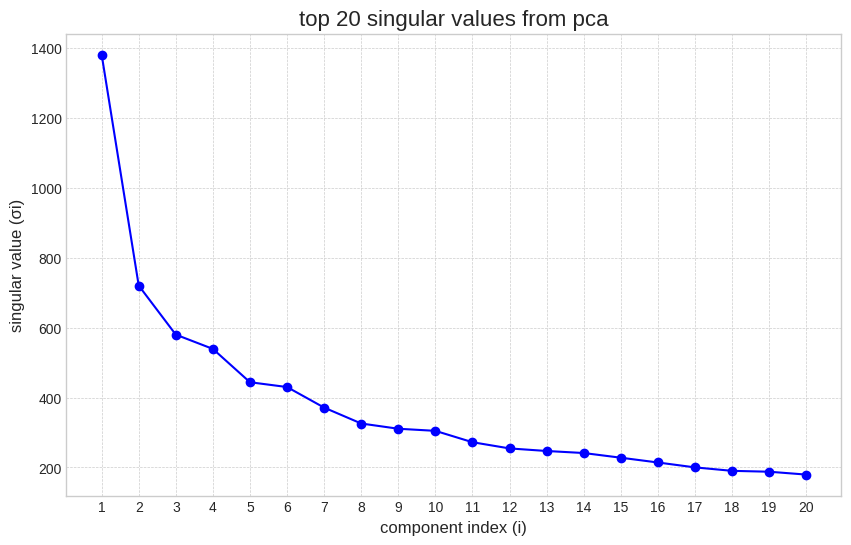

In [ ]:
# --- 5. plot the singular values ---

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), pca.singular_values_, 'o-', color='b')
plt.title('top 20 singular values from pca', fontsize=16)
plt.xlabel('component index (i)', fontsize=12)
plt.ylabel('singular value (σi)', fontsize=12)
plt.xticks(range(1, n_components + 1))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

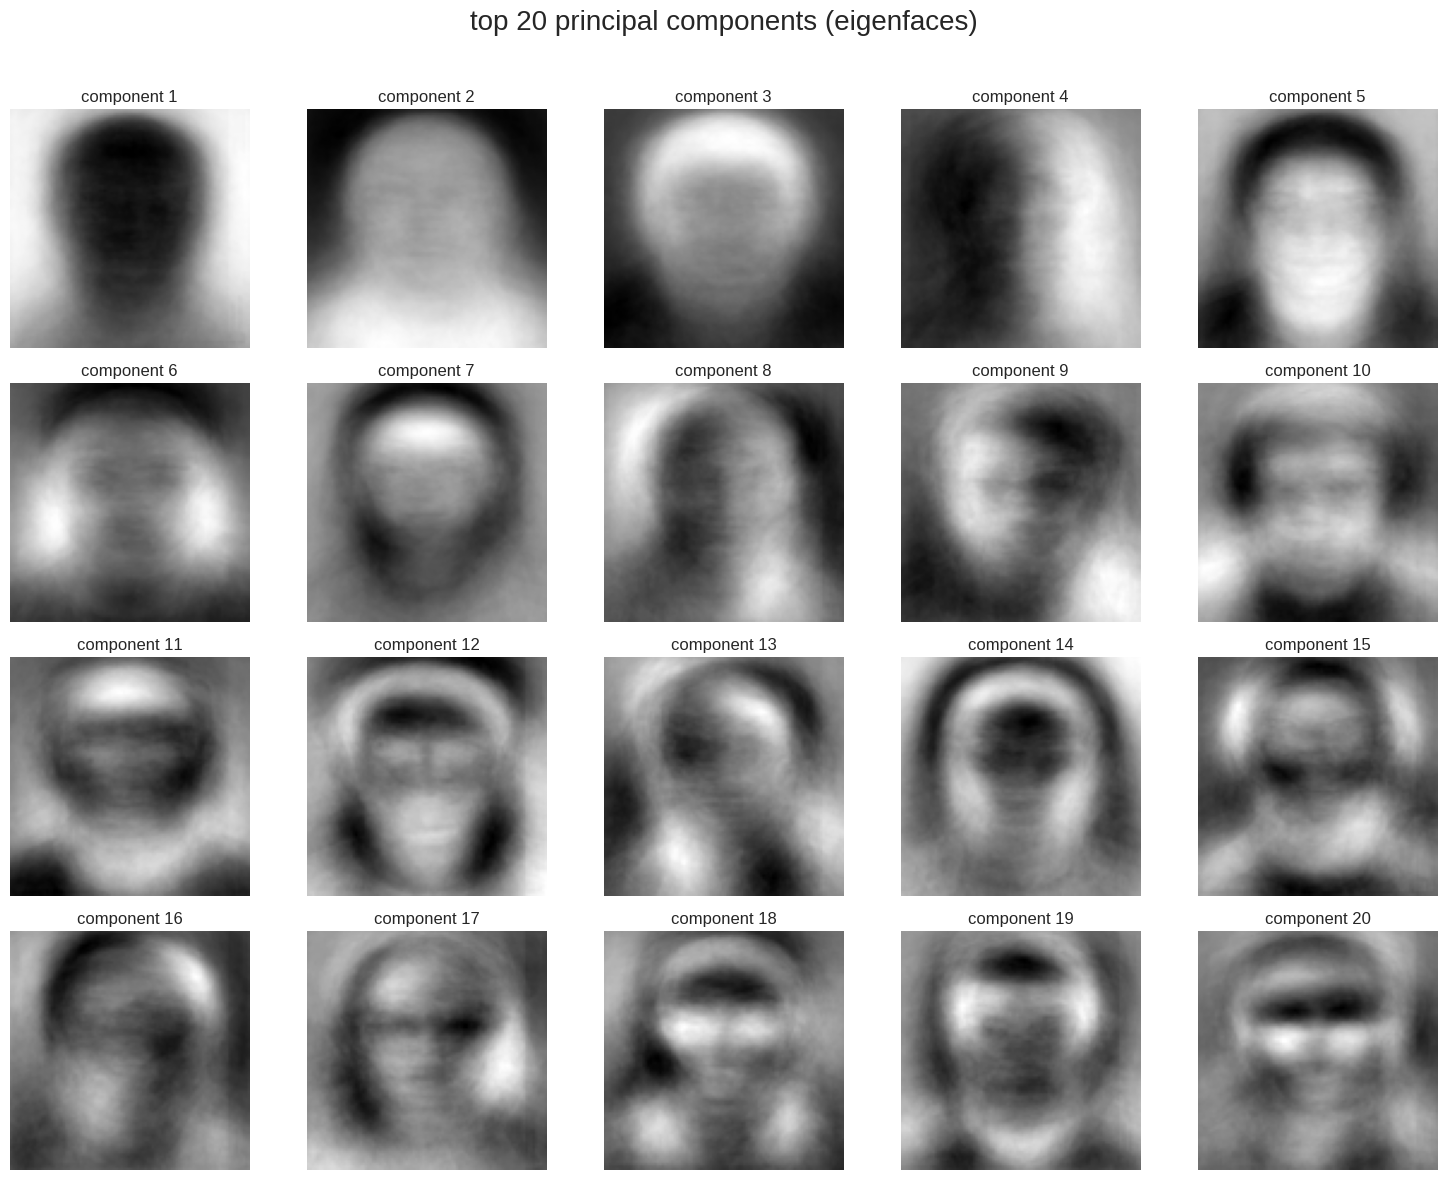

In [ ]:
# --- 6. visualize the principal components (eigenfaces) ---

# the components are the "eigenfaces".
eigenfaces = pca.components_

# create a subplot to display the top 20 eigenfaces.
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('top 20 principal components (eigenfaces)', fontsize=20)

for i, ax in enumerate(axes.flat):
    # reshape the 1d component vector back into a 100x100 image.
    eigenface_image = eigenfaces[i].reshape(image_size)
    ax.imshow(eigenface_image, cmap='gray')
    ax.set_title(f'component {i + 1}')
    ax.axis('off') # hide the x and y axes.

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()